# Historical notebook: pre-migration comparison

        Preserved during the PIRATE 1.5 migration, including its earlier assumptions,
        methods and outputs. It requires its matching older checkout/environment.
        For the current full-band workflow use the notebook with the same name
        one directory above. This historical copy is not validated on PIRATE 1.5.

# Inspecting PIRATE's four peak finders on a fast analytic S/N map

This notebook is derived directly from `inspect_peakfinders_on_snrmap.ipynb`
and preserves its mathematical derivations, explained geometry generators,
footprint plots, four-method execution, physical candidate overlays, decoding,
and containment checks. The only scientific input change is that equivalent
GPU-resident `out_max` and `out_argmax` arrays are generated by
`peakfinder_tests.fast_snrmap.FastSnrMapSimulator` from a real YAML-derived
PIRATE plan.

Exactly four peak finders are inspected: **Bowtie banks**,
**Full-band bowtie**, **Hull**, and **Rectangle**. No channelized-voltage
simulation or end-to-end dedispersion is run.


In [1]:
from pathlib import Path

CONFIG_PATH = Path("configs/dedispersion/chord_sb2.yml")
XENGINE_METADATA_PATH = Path("configs/xengine_metadata.yml")
GPU_DEVICE = 0
SNR_THRESHOLD = 10.0

INJECTED_DM = 100.0
INJECTED_TOAS_S = [9.0, 9.1, 9.15]
INJECTED_SNRS = [45.0, 30.0, 20.0]
INJECTED_WIDTHS_MS = [1.0, 1.0, 1.0]
SPECTRAL_INDEX = 0.0
SCATTERING_MEASURE = 0.0
REQUESTED_TIME_CHUNK_INDEX = 3
TRIAL = 0
BASE_SEED = 12345

DM_REACH = 8
WAIST_BINS = 1
EDGE_POLICY = "exclude"

TIME_WINDOW_S = None
DM_WINDOW = None
DM_REACH_VALUES = [1, 2, 4, 8, 16]
MAX_TABLE_ROWS = 50

TIMING_WARMUP_RUNS = 3
TIMING_MEASURED_RUNS = 20

SAVE_GENERATED_MAP = False
GENERATED_MAP_PATH = Path("peakfinder_tests/generated_fast_snrmap.npz")


## Construct the real plan and generate the analytic map

The plan is constructed by the benchmark suite's `prepare_plan()` helper from
the CHORD dedispersion configuration and X-engine metadata. The tree containing
DM 100 and the one uniquely decoded full observing interval are selected from
that plan; neither is hard-coded.

The three requested TOAs are already dedispersed arrival times at the lowest
edge of the complete observing band. They are passed directly to the simulator,
with no dispersion-delay or infinite-frequency conversion. All pulses use a
1 ms intrinsic Gaussian width, zero spectral index, zero scattering measure,
and the full observing band.


In [2]:
import html
import math
import time

import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import numpy as np
from IPython.display import display

from peakfinder_tests.experiment_common import prepare_plan, tree_for_dm
from peakfinder_tests.fast_snrmap import FastSnrMapSimulator
import peakfinder_tests.peakfinders as pf


class Table:
    # Keep display independent of optional dataframe packages and retain full
    # numerical precision in the underlying ordinary dictionaries.
    def __init__(self, rows=None, columns=None):
        self.rows = list(rows or [])
        self.columns = (
            list(columns) if columns is not None
            else (list(self.rows[0]) if self.rows else [])
        )

    def __len__(self):
        return len(self.rows)

    def head(self, number=5):
        return Table(self.rows[:number], self.columns)

    def _repr_html_(self):
        header = "".join(
            f"<th>{html.escape(str(column))}</th>" for column in self.columns
        )
        body = "".join(
            "<tr>" + "".join(
                f"<td>{html.escape(str(row.get(column, chr(160))))}</td>"
                for column in self.columns
            ) + "</tr>"
            for row in self.rows
        )
        return (
            "<div style='overflow-x:auto'><table><thead><tr>"
            f"{header}</tr></thead><tbody>{body}</tbody></table></div>"
        )


if EDGE_POLICY not in {"exclude", "include"}:
    raise ValueError("EDGE_POLICY must be 'exclude' or 'include'")
if not CONFIG_PATH.is_file() or not XENGINE_METADATA_PATH.is_file():
    raise FileNotFoundError((CONFIG_PATH, XENGINE_METADATA_PATH))
if not (len(INJECTED_TOAS_S) == len(INJECTED_SNRS)
        == len(INJECTED_WIDTHS_MS) == 3):
    raise ValueError("Exactly three TOAs, S/N values, and widths are required")
if not all(np.isfinite(INJECTED_TOAS_S)):
    raise ValueError("Injected TOAs must be finite")
if not all(np.isfinite(INJECTED_SNRS)) or not all(
        value > 0 for value in INJECTED_SNRS):
    raise ValueError("Injected S/N values must be finite and positive")
if not all(np.isfinite(INJECTED_WIDTHS_MS)) or not all(
        value > 0 for value in INJECTED_WIDTHS_MS):
    raise ValueError("Injected widths must be finite and positive")
if not np.allclose(INJECTED_WIDTHS_MS, INJECTED_WIDTHS_MS[0]):
    raise ValueError("FastSnrMapSimulator currently accepts one common width")
if SPECTRAL_INDEX != 0.0 or SCATTERING_MEASURE != 0.0:
    raise ValueError("This controlled full-band experiment requires zero spectral/scattering terms")

config, xmd, plan = prepare_plan(
    str(CONFIG_PATH), str(XENGINE_METADATA_PATH)
)
TREE_INDEX = tree_for_dm(plan, INJECTED_DM)
if TREE_INDEX != 0:
    raise AssertionError(f"DM {INJECTED_DM:g} unexpectedly selected tree {TREE_INDEX}")

time_sample_s = float(config.time_sample_ms) / 1.0e3
nt_in = int(plan.nt_in)
if nt_in != 2048:
    raise AssertionError(f"Expected nt_in=2048, got {nt_in}")

channel_freq_edges_mhz = np.asarray(
    xmd.get_channel_freq_edges(), dtype=np.float64
)
if (channel_freq_edges_mhz.ndim != 1 or channel_freq_edges_mhz.size < 2
        or not np.all(np.diff(channel_freq_edges_mhz) > 0)):
    raise ValueError("X-engine channel edges must be strictly increasing")
reference_frequency_mhz = float(channel_freq_edges_mhz[0])
reference_freq_mhz = reference_frequency_mhz
observing_freq_lo_mhz = float(channel_freq_edges_mhz[0])
observing_freq_hi_mhz = float(channel_freq_edges_mhz[-1])

m_to_band_cpu, plan_subbands, full_band_index = pf.enumerate_plan_subbands(
    plan, TREE_INDEX
)
full_bands = [band for band in plan_subbands if band.is_full_band]
if len(full_bands) != 1 or full_bands[0] is not plan_subbands[full_band_index]:
    raise AssertionError("Plan does not contain one uniquely identified full band")
full_band = full_bands[0]

selected_tree = plan.trees[TREE_INDEX]
dm_min = float(selected_tree.dm_min)
dm_max = float(selected_tree.dm_max)
ndm_out = int(selected_tree.ndm_out)
nt_out = int(selected_tree.nt_out)
dm_step = (dm_max - dm_min) / ndm_out
time_step_s = time_sample_s * nt_in / nt_out
chunk_duration_s = time_sample_s * nt_in

# Derive the common chunk independently from the source TOAs before supplying
# the requested chunk index to the simulator.
derived_chunks = [
    int(math.floor(toa / chunk_duration_s)) for toa in INJECTED_TOAS_S
]
if set(derived_chunks) != {REQUESTED_TIME_CHUNK_INDEX}:
    raise AssertionError(
        f"Injected TOAs fall in chunks {derived_chunks}, not exclusively chunk "
        f"{REQUESTED_TIME_CHUNK_INDEX}"
    )
chunk_start_s = REQUESTED_TIME_CHUNK_INDEX * chunk_duration_s
chunk_stop_s = chunk_start_s + chunk_duration_s
if not all(chunk_start_s <= toa < chunk_stop_s for toa in INJECTED_TOAS_S):
    raise AssertionError("At least one injected TOA lies outside the derived chunk")


def synchronize_gpu():
    cp.cuda.get_current_stream().synchronize()


with cp.cuda.Device(GPU_DEVICE):
    synchronize_gpu()
    construction_start = time.perf_counter()
    simulator = FastSnrMapSimulator(
        plan,
        TREE_INDEX,
        full_band,
        xp=cp,
        time_sample_s=time_sample_s,
        nt_in=nt_in,
        reference_freq_mhz=reference_frequency_mhz,
        injected_dm=INJECTED_DM,
        injected_snr=45.0,
        injected_width_s=INJECTED_WIDTHS_MS[0] / 1.0e3,
        base_seed=BASE_SEED,
    )
    synchronize_gpu()
    simulator_construction_time_ms = 1.0e3 * (
        time.perf_counter() - construction_start
    )

    synchronize_gpu()
    template_start = time.perf_counter()
    analytic_signal_gpu, analytic_argmax_gpu = simulator.signal_template(
        INJECTED_TOAS_S,
        injected_snrs=INJECTED_SNRS,
        time_chunk_index=REQUESTED_TIME_CHUNK_INDEX,
    )
    synchronize_gpu()
    template_generation_time_ms = 1.0e3 * (
        time.perf_counter() - template_start
    )

    synchronize_gpu()
    map_start = time.perf_counter()
    snr_gpu, argmax_gpu, time_chunk_index = simulator.generate_map(
        INJECTED_TOAS_S,
        injected_snrs=INJECTED_SNRS,
        trial=TRIAL,
        time_chunk_index=REQUESTED_TIME_CHUNK_INDEX,
    )
    synchronize_gpu()
    map_generation_time_ms = 1.0e3 * (time.perf_counter() - map_start)

if snr_gpu.dtype != cp.float32:
    raise TypeError(f"snr_gpu dtype is {snr_gpu.dtype}, expected float32")
if argmax_gpu.dtype != cp.uint32:
    raise TypeError(f"argmax_gpu dtype is {argmax_gpu.dtype}, expected uint32")
if snr_gpu.shape != argmax_gpu.shape:
    raise AssertionError("Generated S/N and argmax shapes disagree")
if snr_gpu.shape != (ndm_out, nt_out):
    raise AssertionError(
        f"Generated shape {snr_gpu.shape} != plan shape {(ndm_out, nt_out)}"
    )
if time_chunk_index != REQUESTED_TIME_CHUNK_INDEX:
    raise AssertionError(
        f"Simulator returned chunk {time_chunk_index}, expected "
        f"{REQUESTED_TIME_CHUNK_INDEX}"
    )
if not bool(cp.array_equal(argmax_gpu, analytic_argmax_gpu).item()):
    raise AssertionError("Signal and final map argmax arrays disagree")

analytic_signal_cpu = cp.asnumpy(analytic_signal_gpu)
snr_cpu = cp.asnumpy(snr_gpu)
argmax_cpu = cp.asnumpy(argmax_gpu)
background_cpu = snr_cpu - analytic_signal_cpu

dm_edges = dm_min + np.arange(ndm_out + 1) * dm_step
time_edges = chunk_start_s + np.arange(nt_out + 1) * time_step_s

if SAVE_GENERATED_MAP:
    np.savez_compressed(
        GENERATED_MAP_PATH,
        out_max=snr_cpu,
        out_argmax=argmax_cpu,
        analytic_signal=analytic_signal_cpu,
        injected_dm=np.float64(INJECTED_DM),
        injected_toas_s=np.asarray(INJECTED_TOAS_S, dtype=np.float64),
        injected_snrs=np.asarray(INJECTED_SNRS, dtype=np.float64),
        injected_widths_ms=np.asarray(INJECTED_WIDTHS_MS, dtype=np.float64),
        time_chunk_index=np.int64(time_chunk_index),
        tree_index=np.int64(TREE_INDEX),
        reference_frequency_mhz=np.float64(reference_frequency_mhz),
    )

setup_rows = [{
    "tree index": TREE_INDEX,
    "DM range (pc cm^-3)": f"{dm_min:.9g}--{dm_max:.9g}",
    "map shape": str(snr_gpu.shape),
    "input time resolution (ms)": 1.0e3 * time_sample_s,
    "output time-bin duration (ms)": 1.0e3 * time_step_s,
    "chunk duration (s)": chunk_duration_s,
    "selected sub-band ID": full_band.subband_id,
    "physical frequency interval (MHz)": (
        f"{full_band.freq_lo_MHz:.9g}--{full_band.freq_hi_MHz:.9g}"
    ),
    "reference frequency (MHz)": reference_frequency_mhz,
}]
print(f"DM {INJECTED_DM:g} selects tree {TREE_INDEX} as required.")
print(f"All injected TOAs independently derive chunk {derived_chunks[0]}.")
display(Table(setup_rows))


DM 100 selects tree 0 as required.
All injected TOAs independently derive chunk 3.


tree index,DM range (pc cm^-3),map shape,input time resolution (ms),output time-bin duration (ms),chunk duration (s),selected sub-band ID,physical frequency interval (MHz),reference frequency (MHz)
0,0--1941.0548,"(4096, 128)",1.31072,20.97152,2.68435456,f0_65535,300--1500,300.0


## Initial map-generation diagnostic

The deterministic response contains the three pulses summed at every fine
time/profile state before maximization. The correlated background is generated
once for `(full band, trial 0)`, and `out_max` is their elementwise sum. The
fourth panel decodes the synthetic `out_argmax` multiplet to its plan sub-band.
All panels use the same physical axes; the first three also use one S/N
normalization. Dashed vertical lines mark all injected TOAs, and the horizontal
line/crosses mark DM 100.


simulator construction: 9.059 ms
deterministic template: 102.603 ms
background plus map: 13.438 ms
global maximum: S/N=44.3922 at (idm, itime)=(211, 45)
global decoded: DM=99.992385788 pc cm^-3, TOA=8.999437281 s, sub-band=f0_65535, profile=1
Predicted map locations:


injected TOA (s),injected S/N,predicted idm,predicted itime,predicted decoded DM (pc cm^-3),predicted decoded TOA (s),fine-state index
9.0,45.0,211,45,99.99238578805999,8.999437280515146,2
9.1,30.0,211,49,99.99238578805999,9.100362720515145,15
9.15,20.0,211,52,99.99238578805999,9.150170080515146,5


Measured disjoint local maxima:


injected TOA (s),local maximum S/N,idm,itime,decoded DM (pc cm^-3),decoded TOA (s),sub-band,profile
9.0,44.39219665527344,211,45,99.99238578805999,8.999437280515146,f0_65535,1
9.1,30.607759475708008,211,49,99.99238578805999,9.100362720515145,f0_65535,1
9.15,21.818431854248047,211,52,99.99238578805999,9.150170080515146,f0_65535,1


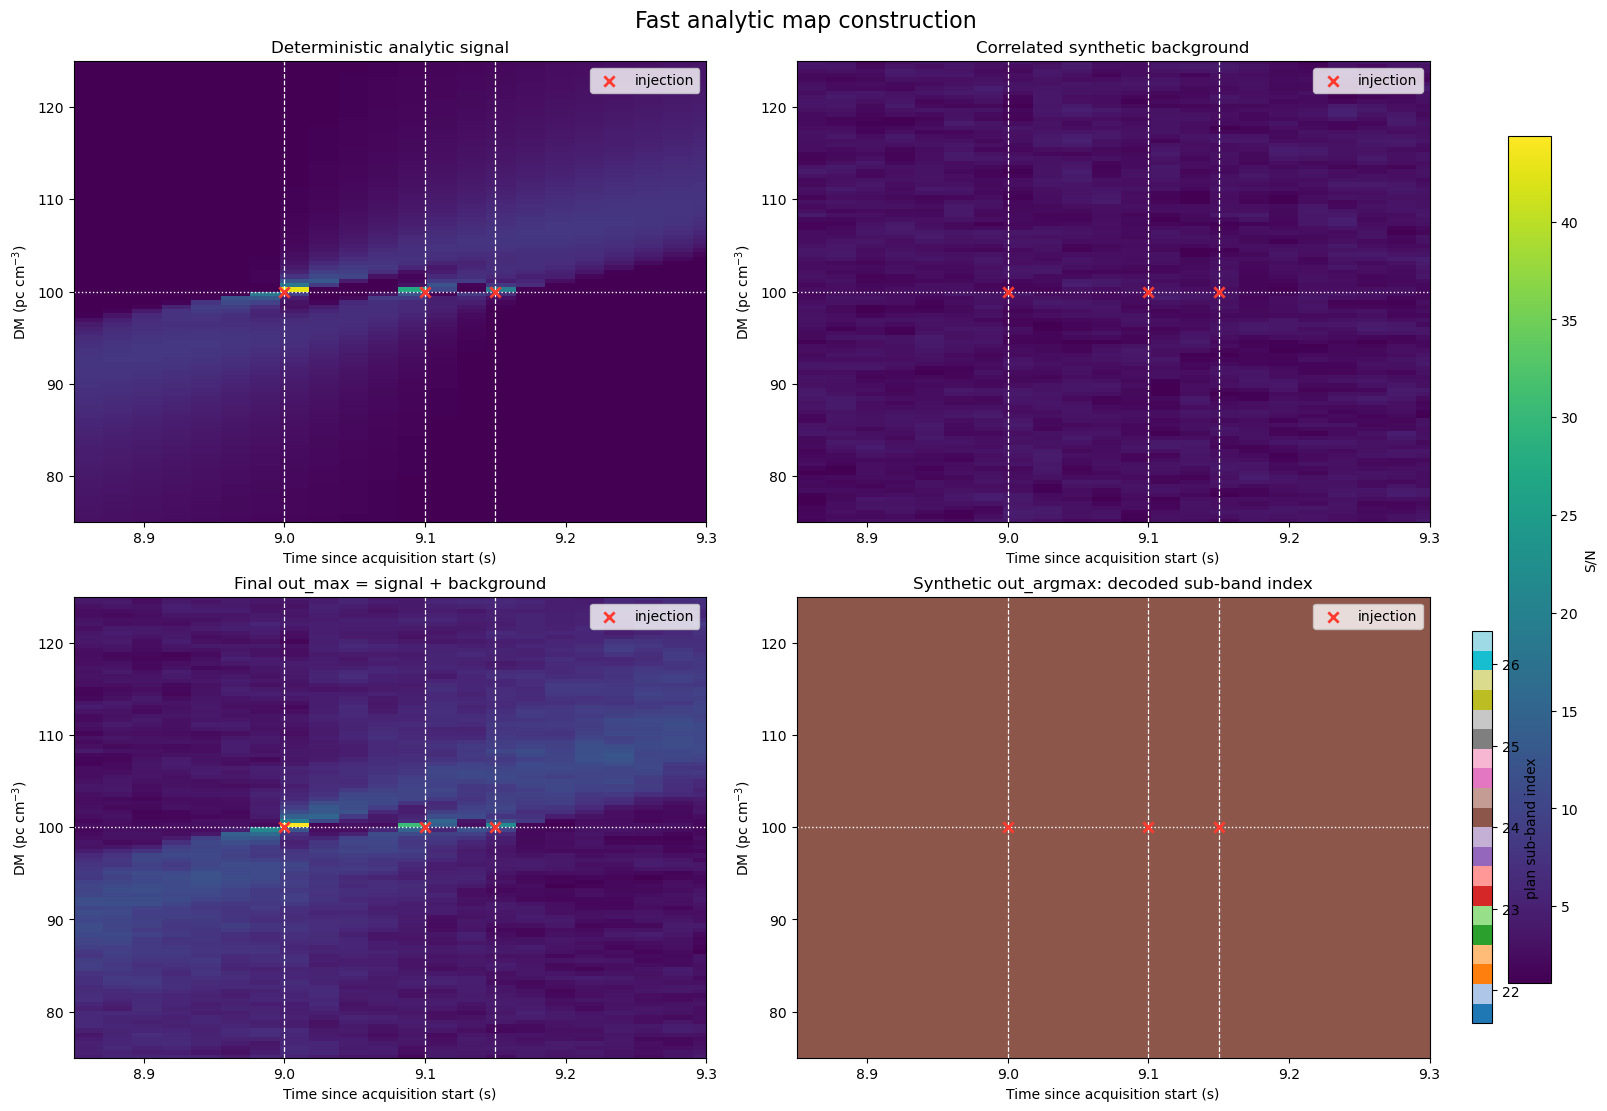

In [3]:
target_idm = int(np.argmin(np.abs(simulator.dm_axis_cpu - INJECTED_DM)))
fine_coordinates_s = (
    simulator.timestamp_by_fine_cpu[:, target_idm, None]
    + np.arange(nt_out, dtype=np.float64)[None, :] * time_step_s
    + chunk_start_s
)

predicted_rows = []
for toa_s, injected_snr in zip(INJECTED_TOAS_S, INJECTED_SNRS):
    fine_index, predicted_itime = np.unravel_index(
        np.argmin(np.abs(fine_coordinates_s - toa_s)),
        fine_coordinates_s.shape,
    )
    predicted_rows.append({
        "injected TOA (s)": toa_s,
        "injected S/N": injected_snr,
        "predicted idm": target_idm,
        "predicted itime": int(predicted_itime),
        "predicted decoded DM (pc cm^-3)": float(simulator.dm_axis_cpu[target_idm]),
        "predicted decoded TOA (s)": float(
            fine_coordinates_s[fine_index, predicted_itime]
        ),
        "fine-state index": int(fine_index),
    })


def decode_one_map_cell(idm, itime, snr_value, token):
    batch = pf.CandidateBatch(
        cp.asarray([idm], dtype=cp.int64),
        cp.asarray([itime], dtype=cp.int64),
        cp.asarray([snr_value], dtype=cp.float32),
        cp.asarray([token], dtype=cp.uint32),
    )
    return pf.decode_candidates(
        plan,
        batch,
        itree=TREE_INDEX,
        time_chunk_index=time_chunk_index,
        ntime=nt_in,
        time_sample_s=time_sample_s,
    )


global_flat = int(cp.argmax(snr_gpu).item())
global_idm, global_itime = divmod(global_flat, nt_out)
global_snr = float(snr_gpu[global_idm, global_itime].item())
global_decoded = decode_one_map_cell(
    global_idm,
    global_itime,
    global_snr,
    int(argmax_cpu[global_idm, global_itime]),
)

# Voronoi time windows bounded by adjacent TOA midpoints keep the measured
# local maxima for the 100 ms and 50 ms pairs disjoint.
toa_midpoints = [
    0.5 * (INJECTED_TOAS_S[index] + INJECTED_TOAS_S[index + 1])
    for index in range(len(INJECTED_TOAS_S) - 1)
]
time_centres_s = 0.5 * (time_edges[:-1] + time_edges[1:])
local_peak_rows = []
for injection_index, toa_s in enumerate(INJECTED_TOAS_S):
    time_lo = (
        toa_s - 2.0 * time_step_s
        if injection_index == 0 else toa_midpoints[injection_index - 1]
    )
    time_hi = (
        toa_s + 2.0 * time_step_s
        if injection_index == len(INJECTED_TOAS_S) - 1
        else toa_midpoints[injection_index]
    )
    time_indices = np.flatnonzero(
        (time_centres_s >= time_lo) & (time_centres_s < time_hi)
    )
    dm_indices = np.arange(
        max(0, target_idm - DM_REACH),
        min(ndm_out, target_idm + DM_REACH + 1),
    )
    local = snr_cpu[np.ix_(dm_indices, time_indices)]
    local_flat = int(np.argmax(local))
    local_dm_offset, local_time_offset = divmod(local_flat, time_indices.size)
    local_idm = int(dm_indices[local_dm_offset])
    local_itime = int(time_indices[local_time_offset])
    local_snr = float(snr_cpu[local_idm, local_itime])
    local_decoded = decode_one_map_cell(
        local_idm,
        local_itime,
        local_snr,
        int(argmax_cpu[local_idm, local_itime]),
    )
    local_peak_rows.append({
        "injected TOA (s)": toa_s,
        "local maximum S/N": local_snr,
        "idm": local_idm,
        "itime": local_itime,
        "decoded DM (pc cm^-3)": float(local_decoded["dm"][0]),
        "decoded TOA (s)": float(local_decoded["toa_ref_s"][0]),
        "sub-band": f"f{int(local_decoded['fmin'][0])}_{int(local_decoded['fmax'][0])}",
        "profile": int(local_decoded["profile"][0]),
    })

injection_locations_passed = all(
    abs(row["decoded DM (pc cm^-3)"] - INJECTED_DM) <= 2.0 * dm_step
    and abs(row["decoded TOA (s)"] - toa_s) <= time_step_s
    and row["local maximum S/N"] > SNR_THRESHOLD
    for row, toa_s in zip(local_peak_rows, INJECTED_TOAS_S)
)
if not injection_locations_passed:
    raise AssertionError("At least one injected burst is absent from its expected map neighbourhood")

pixel_band_gpu = pf.make_pixel_band_map_gpu(
    argmax_gpu, cp.asarray(m_to_band_cpu, dtype=cp.int32)
)
pixel_band_cpu = cp.asnumpy(pixel_band_gpu)

print(f"simulator construction: {simulator_construction_time_ms:.3f} ms")
print(f"deterministic template: {template_generation_time_ms:.3f} ms")
print(f"background plus map: {map_generation_time_ms:.3f} ms")
print(
    f"global maximum: S/N={global_snr:.6g} at "
    f"(idm, itime)=({global_idm}, {global_itime})"
)
print(
    "global decoded: "
    f"DM={global_decoded['dm'][0]:.9f} pc cm^-3, "
    f"TOA={global_decoded['toa_ref_s'][0]:.9f} s, "
    f"sub-band=f{global_decoded['fmin'][0]}_{global_decoded['fmax'][0]}, "
    f"profile={global_decoded['profile'][0]}"
)
print("Predicted map locations:")
display(Table(predicted_rows))
print("Measured disjoint local maxima:")
display(Table(local_peak_rows))

diagnostic_time_limits = (
    min(INJECTED_TOAS_S) - 0.15,
    max(INJECTED_TOAS_S) + 0.15,
)
diagnostic_dm_limits = (INJECTED_DM - 25.0, INJECTED_DM + 25.0)
diagnostic_norm = Normalize(
    vmin=float(np.percentile(background_cpu, 1.0)),
    vmax=float(np.max(snr_cpu)),
)


def mark_injections(ax, *, show_crosses=True):
    ax.axhline(INJECTED_DM, color="white", linestyle=":", linewidth=1.0)
    for index, toa_s in enumerate(INJECTED_TOAS_S):
        ax.axvline(toa_s, color="white", linestyle="--", linewidth=0.9)
        if show_crosses:
            ax.scatter(
                [toa_s], [INJECTED_DM], marker="x", color="#ff3b30",
                linewidths=2.0, s=55, zorder=4,
                label="injection" if index == 0 else None,
            )


fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
for ax, values, title in zip(
    axes.reshape(-1)[:3],
    (analytic_signal_cpu, background_cpu, snr_cpu),
    ("Deterministic analytic signal", "Correlated synthetic background",
     "Final out_max = signal + background"),
):
    image = ax.pcolormesh(
        time_edges, dm_edges, values, cmap="viridis", norm=diagnostic_norm,
        shading="flat", rasterized=True,
    )
    mark_injections(ax)
    ax.set(
        title=title,
        xlabel="Time since acquisition start (s)",
        ylabel=r"DM (pc cm$^{-3}$)",
        xlim=diagnostic_time_limits,
        ylim=diagnostic_dm_limits,
    )
    ax.legend(loc="upper right")

band_image = axes[1, 1].pcolormesh(
    time_edges, dm_edges, pixel_band_cpu, cmap="tab20", shading="flat",
    rasterized=True,
)
mark_injections(axes[1, 1])
axes[1, 1].set(
    title="Synthetic out_argmax: decoded sub-band index",
    xlabel="Time since acquisition start (s)",
    ylabel=r"DM (pc cm$^{-3}$)",
    xlim=diagnostic_time_limits,
    ylim=diagnostic_dm_limits,
)
axes[1, 1].legend(loc="upper right")
fig.colorbar(image, ax=axes.reshape(-1)[:3].tolist(), label="S/N", shrink=0.85)
fig.colorbar(band_image, ax=axes[1, 1], label="plan sub-band index", shrink=0.85)
fig.suptitle("Fast analytic map construction", fontsize=16)
plt.show()


### Analytic-model limitation

The current analytic simulator assigns every `out_argmax` token to the injected
full band, including background pixels. Consequently, in this full-band
experiment **Bowtie banks and Full-band bowtie are expected to use the same
footprint and may return exactly the same candidates**. That agreement follows
from the simplifying token model; it is not evidence that the adaptive
Bowtie-bank implementation is redundant on real maps with heterogeneous winning
sub-bands.

The correlated synthetic background is also only an approximate model. This
notebook is suitable for controlled burst morphology and peak-finder behaviour,
but not for false-alarm or near-threshold conclusions.


## Derivation of the basic bowtie

Let $X[i,j]$ be the generated S/N map, where $i$ is the coarse DM index and
$j$ is the coarse time index. For the selected tree define

$$
\delta_{\rm DM}=\frac{{\rm DM}_{\max}-{\rm DM}_{\min}}{n_{\rm DM,out}},
\qquad
\delta_t=t_{\rm sample}\frac{n_{t,\rm in}}{n_{t,\rm out}}.
$$

For `dm_reach = R`, the footprint visits row offsets
$k\in\{-R,\ldots,R\}$, with physical offsets
$\Delta{\rm DM}_k=k\,\delta_{\rm DM}$. For a searched interval
$[\nu_{\rm lo},\nu_{\rm hi}]$ and observing reference frequency
$\nu_{\rm ref}$, its continuous time edges in **output time-bin units** are

$$
a(k)=\frac{K_{\rm DM}\,\Delta{\rm DM}_k
(\nu_{\rm ref}^{-2}-\nu_{\rm lo}^{-2})}{\delta_t},
\qquad
b(k)=\frac{K_{\rm DM}\,\Delta{\rm DM}_k
(\nu_{\rm ref}^{-2}-\nu_{\rm hi}^{-2})}{\delta_t},
$$

where $K_{\rm DM}=4148.808\ {\rm s}$ when frequencies are in MHz and DM is
in pc cm$^{-3}$. First set

$$
\operatorname{lower}_0(k)=\min(a(k),b(k)),\qquad
\operatorname{upper}_0(k)=\max(a(k),b(k)).
$$

The current implementation uses an intentionally asymmetric waist convention.
For `w = waist_bins`,

$$
\operatorname{lower}(k)=
\begin{cases}
\operatorname{lower}_0(k)-w,&k<0\\
-w,&k=0\\
\operatorname{lower}_0(k),&k>0,
\end{cases}
\quad
\operatorname{upper}(k)=
\begin{cases}
\operatorname{upper}_0(k),&k<0\\
+w,&k=0\\
\operatorname{upper}_0(k)+w,&k>0.
\end{cases}
$$

An integer time offset $l$ is active exactly when
$\operatorname{lower}(k)\leq l\leq\operatorname{upper}(k)$. The allocated
time radius is symmetric,

$$
R_t=\left\lceil\max\left(-\min_k\operatorname{lower}(k),
\max_k\operatorname{upper}(k)\right)\right\rceil,
$$

and membership is evaluated for every integer $l\in[-R_t,R_t]$. Thus:

- `dm_reach` controls the coarse DM rows on either side of the centre, for
  `2 * dm_reach + 1` total rows and physical half-reach
  `dm_reach * delta_DM`;
- increasing `dm_reach` also increases the footprint's temporal extent through
  the dispersion-delay slopes;
- `waist_bins` is measured in output time bins and has physical duration
  `waist_bins * delta_t`;
- both parameters have different physical meanings in different trees; and
- discretization can make physically different sub-band bowties collapse to
  exactly the same boolean mask.


## The four local-maximum geometries

For a centred footprint $F$, all four methods use the same condition at centre
$p$:

$$
X[p] > T,\qquad X[p]=\max_{q\in p+F}X[q].
$$

The threshold comparison is strict. Equality with the local maximum is not
strict, so distinct equal-valued tied maxima may survive. With
`EDGE_POLICY="exclude"`, `maximum_filter` supplies $+\infty$ outside the map;
therefore any centre whose active footprint crosses a map boundary cannot equal
its filtered maximum and is rejected.

### 1. Bowtie banks

The centre pixel's `argmax` token identifies its multiplet and hence its winning
searched frequency interval. **Only the centre token selects the footprint.**
Neighbour tokens neither select nor modify that centre's footprint, although
all neighbouring S/N values still come from the common `out_max` map. Continuous
intervals can discretize to identical masks, so the bank is deduplicated by
exact boolean-mask equality before filtering.

### 2. Full-band bowtie

This method filters with the bowtie generated directly from the one uniquely
decoded full observing interval: `geometry.full_band_footprint`. The centred
union of all bank masks is retained only as an invariant check. For this plan it
must equal the directly generated full-band footprint; the union is not the
filtering operation.

### 3. Hull

The Hull contains every lattice cell inside or on the discrete convex hull of
the active full-band-bowtie offsets. It fills concave regions while preserving
the smallest convex discrete geometry that contains the full-band bowtie.

### 4. Rectangle

The Rectangle is the smallest centred, axis-aligned, all-True rectangle that
contains the full-band bowtie. Its DM and time radii are the maximum absolute
active offsets of that source footprint.

The intended footprint containment is

$$
F_{\rm subband}\subseteq F_{\rm full}\subseteq F_{\rm hull}
\subseteq F_{\rm rectangle},
$$

and the centred union of every sub-band bowtie equals $F_{\rm full}$. A larger
maximum-filter footprint can only keep the same number or fewer centres, so the
candidate containment reverses:

$$
C_{\rm rectangle}\subseteq C_{\rm hull}\subseteq C_{\rm full}
\subseteq C_{\rm banks}.
$$


In [4]:
import peakfinder_tests.peakfinders as pf

if tuple(pf.METHODS) != (
    "bowtie_banks", "full_band_bowtie", "hull", "rectangle"
):
    raise RuntimeError(f"Unexpected current methods: {pf.METHODS}")

with cp.cuda.Device(GPU_DEVICE):
    geometry = pf.build_peakfinder_geometry(
        plan,
        TREE_INDEX,
        time_sample_s=time_sample_s,
        nt_in=nt_in,
        reference_freq_mhz=reference_freq_mhz,
        dm_reach=DM_REACH,
        waist_bins=WAIST_BINS,
    )

assert geometry.ndm == ndm_out and geometry.nt == nt_out
assert np.isclose(geometry.dm_step, dm_step)
assert np.isclose(geometry.time_step_s, time_step_s)
print(
    f"Current module geometry: {len(geometry.subbands)} decoded intervals, "
    f"{len(geometry.unique_footprints)} exactly unique bowties"
)


Current module geometry: 25 decoded intervals, 25 exactly unique bowties


## Explained geometry generators: bowties, exact deduplication, and union

The following `_explained` functions reproduce the current module's numerical
geometry logic for inspection only. They are never used to select or decode
candidates. Comments focus on how physical offsets become centred discrete
masks and why exact operations are used.


In [5]:
K_DM_EXPLAINED = 4148.808


def make_subband_bowtie_gpu_explained(
        dm_reach, dm_step, time_step_s, freq_lo_mhz, freq_hi_mhz,
        reference_freq_mhz, waist_bins):
    '''Construct one searched interval's discrete bowtie on the GPU.'''
    if dm_reach < 0 or waist_bins < 0:
        raise ValueError("Bowtie reach and waist must be non-negative")
    if not reference_freq_mhz <= freq_lo_mhz < freq_hi_mhz:
        raise ValueError("Invalid reference/sub-band frequency ordering")

    # These are physical DM offsets from the candidate centre. Their spacing
    # is the selected tree's coarse DM-map step, not 1 pc cm^-3.
    dm_offsets = (
        cp.arange(-dm_reach, dm_reach + 1, dtype=cp.float64) * dm_step
    )

    # Each band edge supplies a dispersion-delay slope relative to the
    # observing reference frequency. Dividing by the tree's output time step
    # expresses both continuous edges in coarse output-bin coordinates.
    slope_lo = K_DM_EXPLAINED * (
        reference_freq_mhz**-2 - freq_lo_mhz**-2
    )
    slope_hi = K_DM_EXPLAINED * (
        reference_freq_mhz**-2 - freq_hi_mhz**-2
    )
    edge_a = dm_offsets * slope_lo / time_step_s
    edge_b = dm_offsets * slope_hi / time_step_s
    lower = cp.minimum(edge_a, edge_b)
    upper = cp.maximum(edge_a, edge_b)

    # The waist extends the later-time edge for positive DM offsets and the
    # earlier-time edge for negative offsets. The central row explicitly spans
    # [-waist_bins, +waist_bins], matching the asymmetric convention derived
    # above rather than applying a symmetric dilation to every row.
    upper[dm_offsets > 0] += waist_bins
    lower[dm_offsets < 0] -= waist_bins
    lower[dm_offsets == 0] = -waist_bins
    upper[dm_offsets == 0] = waist_bins

    # A symmetric radius produces an odd number of columns with a unique
    # central time cell. Some allocated edge cells may remain False; allocation
    # and physical membership are intentionally separate.
    time_reach = int(
        cp.ceil(cp.maximum(-lower.min(), upper.max())).item()
    )
    time_offsets = cp.arange(
        -time_reach, time_reach + 1, dtype=cp.int32
    )
    return (
        (time_offsets[None, :] >= lower[:, None])
        & (time_offsets[None, :] <= upper[:, None])
    )


def deduplicate_bowtie_bank_gpu_explained(footprints):
    '''Remove exact duplicate masks while retaining every interval mapping.'''
    unique_footprints, unique_cpu, unique_to_bands = [], [], []
    band_to_unique = np.empty(len(footprints), dtype=np.int32)
    fingerprint_buckets = {}
    for band, footprint_gpu in enumerate(footprints):
        footprint_cpu = np.ascontiguousarray(
            cp.asnumpy(footprint_gpu), dtype=np.bool_
        )

        # Shape plus packed boolean bits is an exact fingerprint candidate.
        # The subsequent array_equal check makes collisions harmless: no
        # geometrically distinct mask is merged by tolerance or summary value.
        fingerprint = (
            footprint_cpu.shape,
            np.packbits(footprint_cpu.reshape(-1)).tobytes(),
        )
        matched_unique = None
        for unique_index in fingerprint_buckets.get(fingerprint, []):
            candidate = unique_cpu[unique_index]
            if (candidate.shape == footprint_cpu.shape
                    and np.array_equal(candidate, footprint_cpu)):
                matched_unique = unique_index
                break
        if matched_unique is None:
            matched_unique = len(unique_footprints)
            unique_footprints.append(footprint_gpu)
            unique_cpu.append(footprint_cpu)
            unique_to_bands.append([])
            fingerprint_buckets.setdefault(fingerprint, []).append(
                matched_unique
            )
        band_to_unique[band] = matched_unique
        unique_to_bands[matched_unique].append(band)
    return unique_footprints, band_to_unique, unique_to_bands


def _require_odd_centered_footprint_explained(footprint, name):
    if (footprint.ndim != 2
            or any(size < 1 or size % 2 == 0 for size in footprint.shape)):
        raise ValueError(
            f"{name} must be non-empty, 2-D and odd-shaped; got {footprint.shape}"
        )


def make_union_bowtie_gpu_explained(footprints):
    '''Return a minimally cropped centred union for invariant checking.'''
    if not footprints:
        raise ValueError("At least one footprint is required")
    for index, footprint in enumerate(footprints):
        _require_odd_centered_footprint_explained(
            footprint, f"footprint {index}"
        )

    # Different bands can have different time radii. Padding them onto a common
    # centred grid before OR-ing preserves the meaning of every (delta DM,
    # delta time) cell; top-left alignment would shift smaller footprints.
    dm_radius = max(footprint.shape[0] // 2 for footprint in footprints)
    time_radius = max(footprint.shape[1] // 2 for footprint in footprints)
    union = cp.zeros(
        (2 * dm_radius + 1, 2 * time_radius + 1), dtype=cp.bool_
    )
    for footprint in footprints:
        radius_dm = footprint.shape[0] // 2
        radius_time = footprint.shape[1] // 2
        dm_start = dm_radius - radius_dm
        time_start = time_radius - radius_time
        union[
            dm_start:dm_start + footprint.shape[0],
            time_start:time_start + footprint.shape[1],
        ] |= footprint

    active_dm, active_time = cp.nonzero(union)
    if active_dm.size == 0:
        raise ValueError("Union footprint is empty")

    # Symmetric cropping retains an odd shape and the same physical centre even
    # if the outer allocated rows or columns contain no active cells.
    radius_dm = int(cp.max(cp.abs(active_dm - dm_radius)).item())
    radius_time = int(cp.max(cp.abs(active_time - time_radius)).item())
    return union[
        dm_radius - radius_dm:dm_radius + radius_dm + 1,
        time_radius - radius_time:time_radius + radius_time + 1,
    ]


## Explained geometry generators: integer hull and bounding rectangle

Active cells are represented by integer `(delta time, delta DM)` coordinates.
Integer cross products make orientation and boundary tests exact, avoiding a
floating-point tolerance in the discrete convex-hull construction.


In [6]:
def _cross_explained(origin, a, b):
    '''Signed twice-area: positive means an anticlockwise turn.'''
    return (
        (a[0] - origin[0]) * (b[1] - origin[1])
        - (a[1] - origin[1]) * (b[0] - origin[0])
    )


def _convex_hull_vertices_integer_explained(points):
    '''Return strict boundary vertices with the monotone-chain algorithm.'''
    points = sorted(set(tuple(map(int, point)) for point in points))
    if len(points) <= 1:
        return points

    # Collinear points between endpoints do not define new hull edges. Removing
    # them here leaves the smallest ordered vertex list for exact half-plane
    # membership tests below.
    lower = []
    for point in points:
        while (len(lower) >= 2
               and _cross_explained(lower[-2], lower[-1], point) <= 0):
            lower.pop()
        lower.append(point)
    upper = []
    for point in reversed(points):
        while (len(upper) >= 2
               and _cross_explained(upper[-2], upper[-1], point) <= 0):
            upper.pop()
        upper.append(point)
    return lower[:-1] + upper[:-1]


def _inside_or_on_convex_hull_explained(point, hull):
    '''Test exact integer membership, including every hull boundary.'''
    if len(hull) == 1:
        return point == hull[0]
    if len(hull) == 2:
        return (
            _cross_explained(hull[0], hull[1], point) == 0
            and min(hull[0][0], hull[1][0])
            <= point[0] <= max(hull[0][0], hull[1][0])
            and min(hull[0][1], hull[1][1])
            <= point[1] <= max(hull[0][1], hull[1][1])
        )
    return all(
        _cross_explained(hull[index], hull[(index + 1) % len(hull)], point)
        >= 0
        for index in range(len(hull))
    )


def make_convex_hull_bowtie_gpu_explained(source_footprint):
    '''Fill every lattice centre inside/on the source mask's convex hull.'''
    _require_odd_centered_footprint_explained(
        source_footprint, "source footprint"
    )
    source_cpu = np.ascontiguousarray(
        cp.asnumpy(source_footprint), dtype=np.bool_
    )
    center_dm, center_time = np.asarray(source_cpu.shape) // 2

    # Subtracting the unique array centre converts active array indices to the
    # centred integer geometry used by all footprint containment statements.
    points = [
        (int(itime - center_time), int(idm - center_dm))
        for idm, itime in np.argwhere(source_cpu)
    ]
    hull_vertices = _convex_hull_vertices_integer_explained(points)
    hull_cpu = np.zeros_like(source_cpu)
    for idm in range(source_cpu.shape[0]):
        for itime in range(source_cpu.shape[1]):
            hull_cpu[idm, itime] = _inside_or_on_convex_hull_explained(
                (itime - center_time, idm - center_dm), hull_vertices
            )
    if not np.all(hull_cpu[source_cpu]):
        raise AssertionError("Discrete convex hull lost an active source cell")
    return cp.asarray(hull_cpu), hull_vertices


def make_bowtie_bounding_rectangle_gpu_explained(source_footprint):
    '''Return the minimal centred all-True rectangle around active cells.'''
    _require_odd_centered_footprint_explained(
        source_footprint, "source footprint"
    )
    active_dm, active_time = cp.nonzero(source_footprint)
    center_dm, center_time = (
        size // 2 for size in source_footprint.shape
    )

    # Maximum absolute active offsets are the smallest symmetric radii that
    # retain the centred full-band geometry on each axis.
    radius_dm = int(cp.max(cp.abs(active_dm - center_dm)).item())
    radius_time = int(cp.max(cp.abs(active_time - center_time)).item())
    return cp.ones(
        (2 * radius_dm + 1, 2 * radius_time + 1), dtype=cp.bool_
    )


## Exact reproduction and footprint-containment checks

This cell independently regenerates the explanatory masks, then requires exact
shape and cell equality with the current reusable module. A discrepancy raises
an error at the first named geometry; it is never repaired by altering the
module from inside this notebook.


In [7]:
def assert_same_mask(name, explained, current):
    if explained.shape != current.shape:
        raise AssertionError(
            f"{name}: explained shape {explained.shape} != current {current.shape}"
        )
    if not bool(cp.array_equal(explained, current).item()):
        different = int(cp.count_nonzero(explained != current).item())
        raise AssertionError(f"{name}: {different} boolean cells differ")


with cp.cuda.Device(GPU_DEVICE):
    explained_original = [
        make_subband_bowtie_gpu_explained(
            DM_REACH,
            dm_step,
            time_step_s,
            band.freq_lo_MHz,
            band.freq_hi_MHz,
            reference_freq_mhz,
            WAIST_BINS,
        )
        for band in geometry.subbands
    ]
    current_original = [
        pf.make_subband_bowtie_gpu(
            DM_REACH,
            dm_step,
            time_step_s,
            band.freq_lo_MHz,
            band.freq_hi_MHz,
            reference_freq_mhz,
            WAIST_BINS,
        )
        for band in geometry.subbands
    ]
    for band, explained, current in zip(
            geometry.subbands, explained_original, current_original):
        assert_same_mask(band.subband_id, explained, current)

    explained_unique, explained_band_to_unique, explained_unique_to_bands = (
        deduplicate_bowtie_bank_gpu_explained(explained_original)
    )
    if not np.array_equal(
            explained_band_to_unique, cp.asnumpy(geometry.band_to_unique)):
        raise AssertionError("Explained band-to-unique mapping differs from the module")
    if tuple(tuple(group) for group in explained_unique_to_bands) != geometry.unique_to_bands:
        raise AssertionError("Explained unique-to-band mapping differs from the module")
    if len(explained_unique) != len(geometry.unique_footprints):
        raise AssertionError("Explained unique-bank size differs from the module")
    for unique_index, (explained, current) in enumerate(
            zip(explained_unique, geometry.unique_footprints)):
        assert_same_mask(f"unique bowtie {unique_index}", explained, current)

    explained_full = explained_original[geometry.full_band_index]
    assert_same_mask(
        "direct full-band bowtie", explained_full, geometry.full_band_footprint
    )
    explained_union = make_union_bowtie_gpu_explained(explained_original)
    current_union = pf.make_union_bowtie_gpu(current_original)
    assert_same_mask("centred union (explained/current)", explained_union, current_union)
    assert_same_mask("centred union/direct full band", explained_union, explained_full)

    explained_hull, explained_hull_vertices = (
        make_convex_hull_bowtie_gpu_explained(explained_full)
    )
    assert_same_mask("Hull", explained_hull, geometry.hull_footprint)
    if tuple(explained_hull_vertices) != geometry.hull_vertices:
        raise AssertionError("Explained integer hull vertices differ from the module")

    explained_rectangle = make_bowtie_bounding_rectangle_gpu_explained(
        explained_full
    )
    assert_same_mask("Rectangle", explained_rectangle, geometry.rectangle_footprint)


def checked_offsets(name, footprint):
    if footprint.ndim != 2 or any(
            size < 1 or size % 2 == 0 for size in footprint.shape):
        raise AssertionError(f"{name} is not non-empty, 2-D, and odd-shaped")
    center = tuple(size // 2 for size in footprint.shape)
    if not bool(footprint[center].item()):
        raise AssertionError(f"{name} does not contain its central cell")
    return pf.centered_active_offsets_cpu(footprint)


full_offsets = checked_offsets("Full-band bowtie", geometry.full_band_footprint)
subband_offsets = []
for band, footprint in zip(geometry.subbands, current_original):
    offsets = checked_offsets(band.subband_id, footprint)
    if not offsets <= full_offsets:
        raise AssertionError(f"{band.subband_id} is not a centred full-band subset")
    subband_offsets.append(offsets)
for unique_index, footprint in enumerate(geometry.unique_footprints):
    checked_offsets(f"unique bowtie {unique_index}", footprint)
union_offsets = checked_offsets("centred union", explained_union)
hull_offsets = checked_offsets("Hull", geometry.hull_footprint)
rectangle_offsets = checked_offsets("Rectangle", geometry.rectangle_footprint)

if union_offsets != full_offsets:
    raise AssertionError("Centred union is not exactly the direct full-band bowtie")
if not full_offsets <= hull_offsets <= rectangle_offsets:
    raise AssertionError("Expected Full-band subset Hull subset Rectangle")

geometry_reproduction_passed = True
footprint_containment_passed = True
print("PASS: notebook-local generators exactly reproduce every module geometry.")
print("PASS: all footprint shape, centre, union, and containment checks hold.")


PASS: notebook-local generators exactly reproduce every module geometry.
PASS: all footprint shape, centre, union, and containment checks hold.


## Every unique Bowtie-bank footprint

There is no representative bank footprint: each centre selects the mask for its
own winning interval. The table maps every exactly unique mask back to all
decoded intervals that use it. Each plotted cell has physical size
`dm_step` by `time_step`; the red open marker identifies the central cell.


unique footprint,stable sub-band ID,fmin,fmax,frequency interval (MHz),hierarchy level,order within level,full observing band,mask shape,active cells
0,f0_4095,0,4095,948.683298--1500,0,0,False,"(17, 19)",29
1,f4096_8191,4096,8191,750--948.683298,0,1,False,"(17, 19)",21
2,f8192_12287,8192,12287,639.602149--750,0,2,False,"(17, 17)",25
3,f12288_16383,12288,16383,566.94671--639.602149,0,3,False,"(17, 17)",25
4,f16384_20479,16384,20479,514.495755--566.94671,0,4,False,"(17, 15)",21
5,f0_8191,0,8191,750--1500,1,0,False,"(17, 19)",31
6,f4096_12287,4096,12287,639.602149--948.683298,1,1,False,"(17, 19)",25
7,f8192_16383,8192,16383,566.94671--750,1,2,False,"(17, 17)",31
8,f12288_20479,12288,20479,514.495755--639.602149,1,3,False,"(17, 17)",27
9,f16384_24575,16384,24575,474.341649--566.94671,1,4,False,"(17, 15)",25


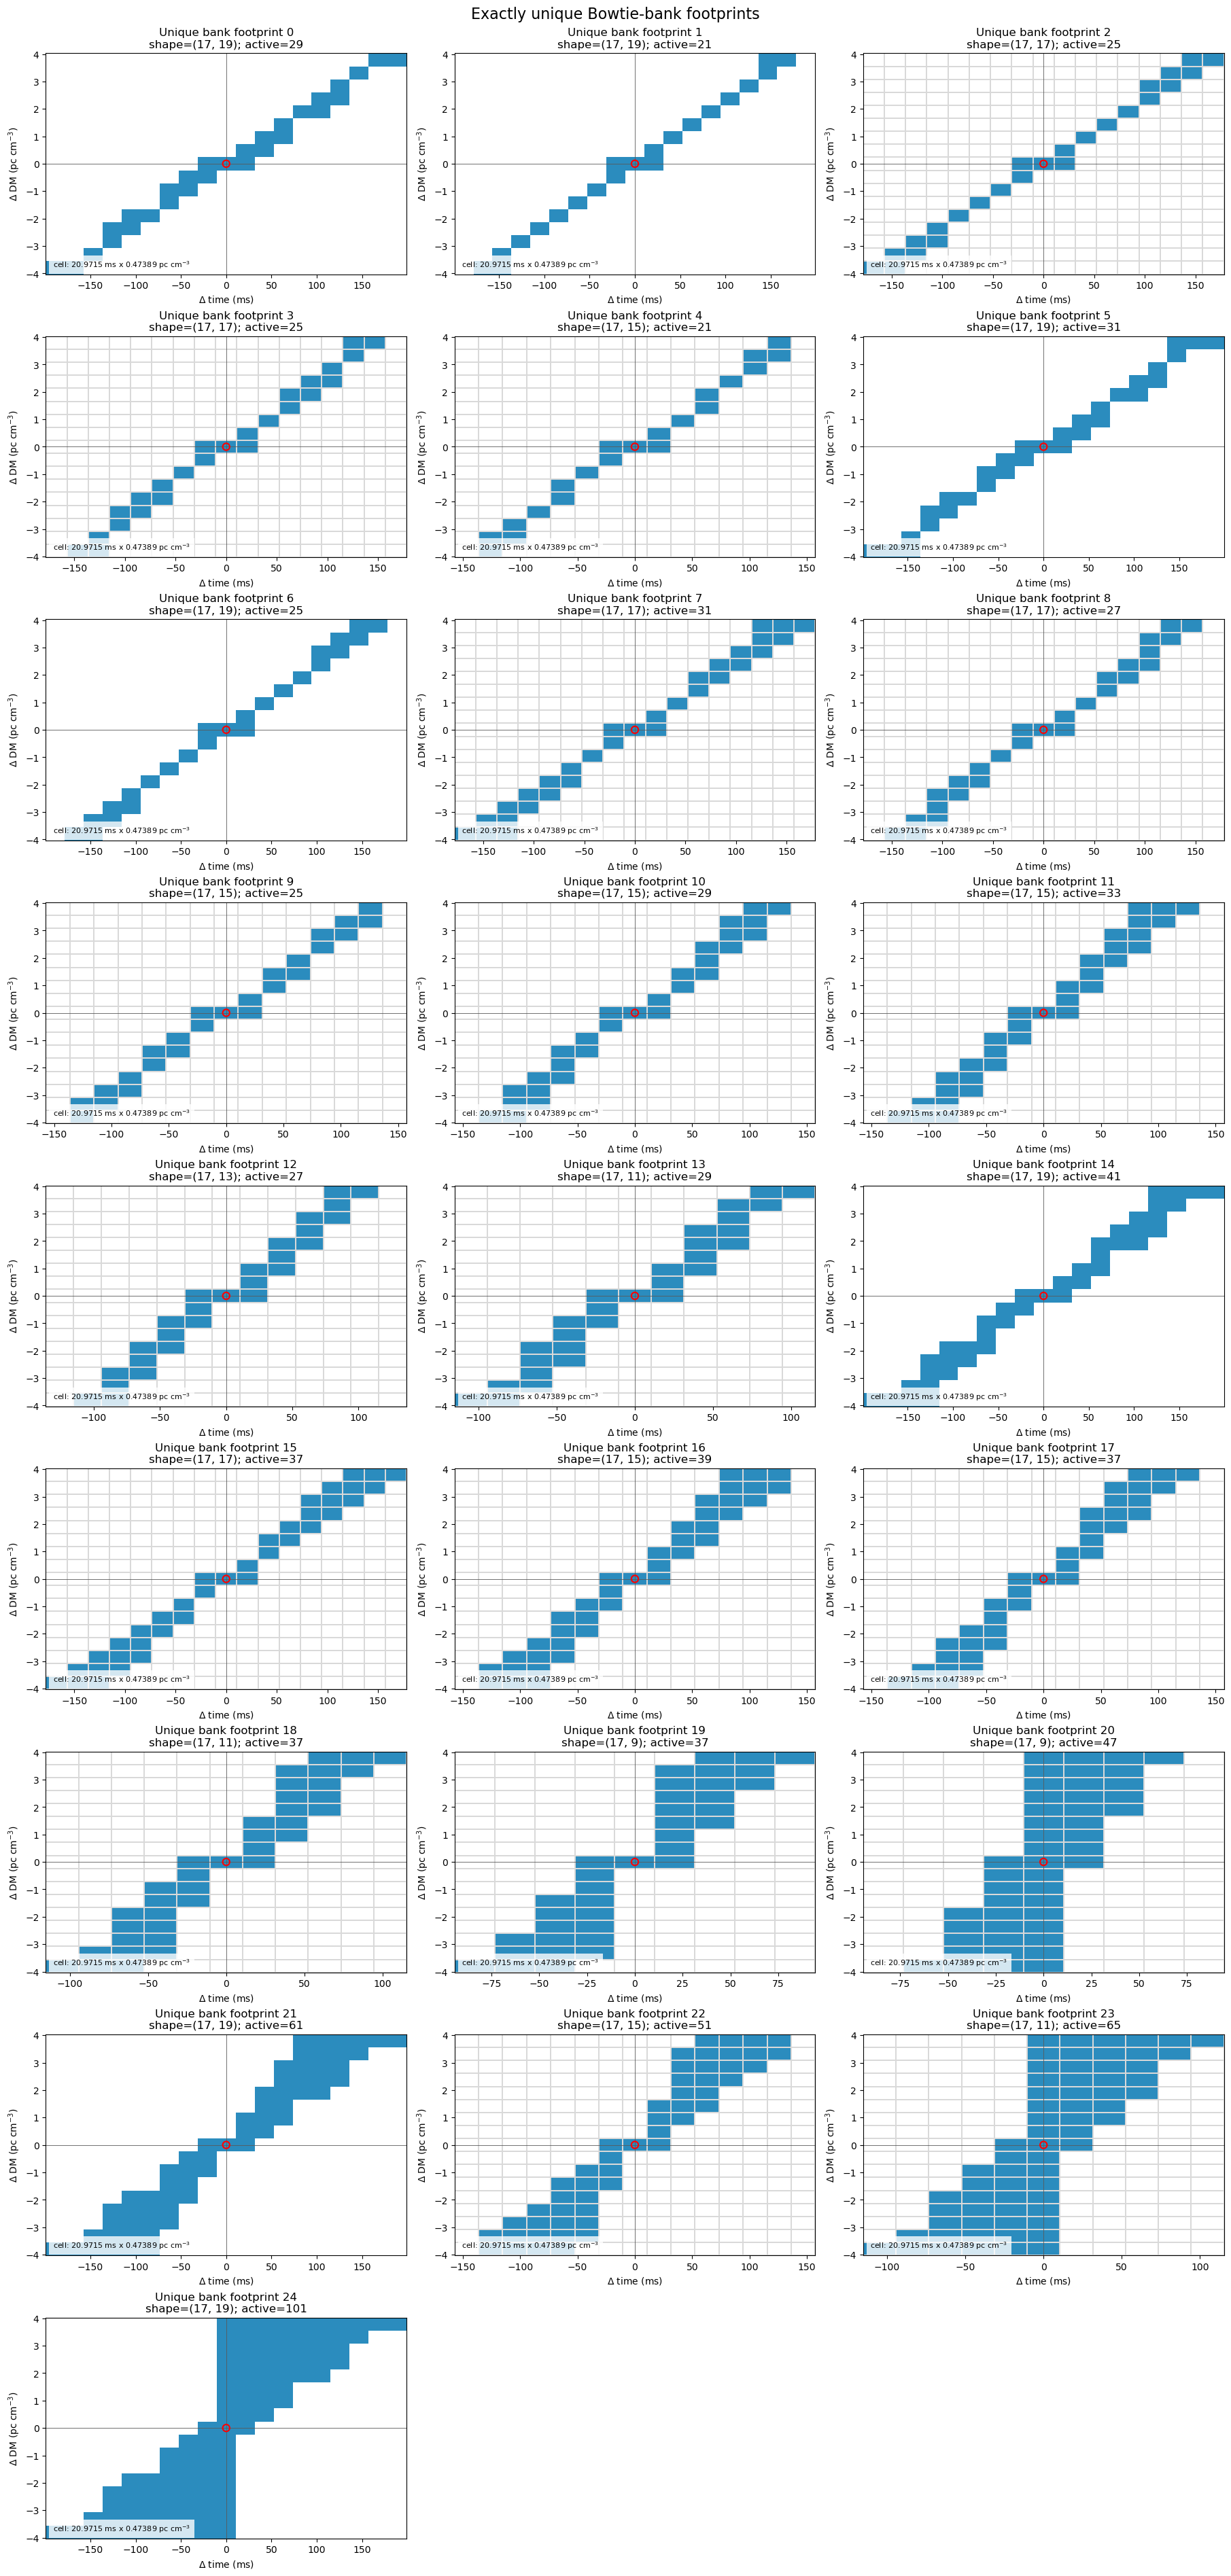

In [8]:
def footprint_stats_cpu(footprint):
    mask = np.ascontiguousarray(cp.asnumpy(footprint), dtype=np.bool_)
    return mask, int(np.count_nonzero(mask))


bank_mapping_rows = []
for unique_index, band_indices in enumerate(geometry.unique_to_bands):
    footprint = geometry.unique_footprints[unique_index]
    _, active_cells = footprint_stats_cpu(footprint)
    for band_index in band_indices:
        band = geometry.subbands[band_index]
        bank_mapping_rows.append({
            "unique footprint": unique_index,
            "stable sub-band ID": band.subband_id,
            "fmin": band.fmin,
            "fmax": band.fmax,
            "frequency interval (MHz)": (
                f"{band.freq_lo_MHz:.9g}--{band.freq_hi_MHz:.9g}"
            ),
            "hierarchy level": band.level,
            "order within level": band.order_within_level,
            "full observing band": band.is_full_band,
            "mask shape": str(tuple(footprint.shape)),
            "active cells": active_cells,
        })

bank_mapping_table = Table(bank_mapping_rows)
display(bank_mapping_table)


FOOTPRINT_CMAP = ListedColormap(["white", "#2b8cbe"])


def plot_footprint_physical(ax, footprint, title, *, xlim=None, ylim=None):
    mask, active_cells = footprint_stats_cpu(footprint)
    radius_dm, radius_time = np.asarray(mask.shape) // 2
    time_edges_ms = (
        np.arange(-radius_time - 0.5, radius_time + 1.5) * time_step_s * 1.0e3
    )
    dm_edges_physical = (
        np.arange(-radius_dm - 0.5, radius_dm + 1.5) * dm_step
    )
    ax.pcolormesh(
        time_edges_ms,
        dm_edges_physical,
        mask.astype(np.int8),
        cmap=FOOTPRINT_CMAP,
        vmin=0,
        vmax=1,
        shading="flat",
        edgecolors="0.85" if mask.size <= 300 else "none",
        linewidth=0.25,
    )
    ax.scatter(
        [0.0], [0.0], marker="o", facecolors="none", edgecolors="red",
        linewidths=1.5, s=55, zorder=3,
    )
    ax.axhline(0.0, color="0.35", linewidth=0.6)
    ax.axvline(0.0, color="0.35", linewidth=0.6)
    ax.set(
        title=f"{title}\nshape={mask.shape}; active={active_cells}",
        xlabel=r"$\Delta$ time (ms)",
        ylabel=r"$\Delta$ DM (pc cm$^{-3}$)",
    )
    ax.text(
        0.02,
        0.02,
        f"cell: {time_step_s * 1e3:.6g} ms x {dm_step:.6g} pc cm$^{{-3}}$",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom",
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)


nunique = len(geometry.unique_footprints)
ncols = min(3, nunique)
nrows = int(np.ceil(nunique / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(6 * ncols, 4.2 * nrows), constrained_layout=True
)
axes = np.atleast_1d(axes).reshape(-1)
for unique_index, footprint in enumerate(geometry.unique_footprints):
    plot_footprint_physical(
        axes[unique_index], footprint, f"Unique bank footprint {unique_index}"
    )
for ax in axes[nunique:]:
    ax.set_visible(False)
fig.suptitle("Exactly unique Bowtie-bank footprints", fontsize=16)
plt.show()


## Full-band bowtie, Hull, and Rectangle

These are the three fixed footprints used by the corresponding methods. Their
panels share identical physical limits, making the filled concavities and the
bounding rectangle directly comparable. The centred bank union is not shown as
a fourth method because it is only an invariant and is exactly equal to the
direct full-band mask.


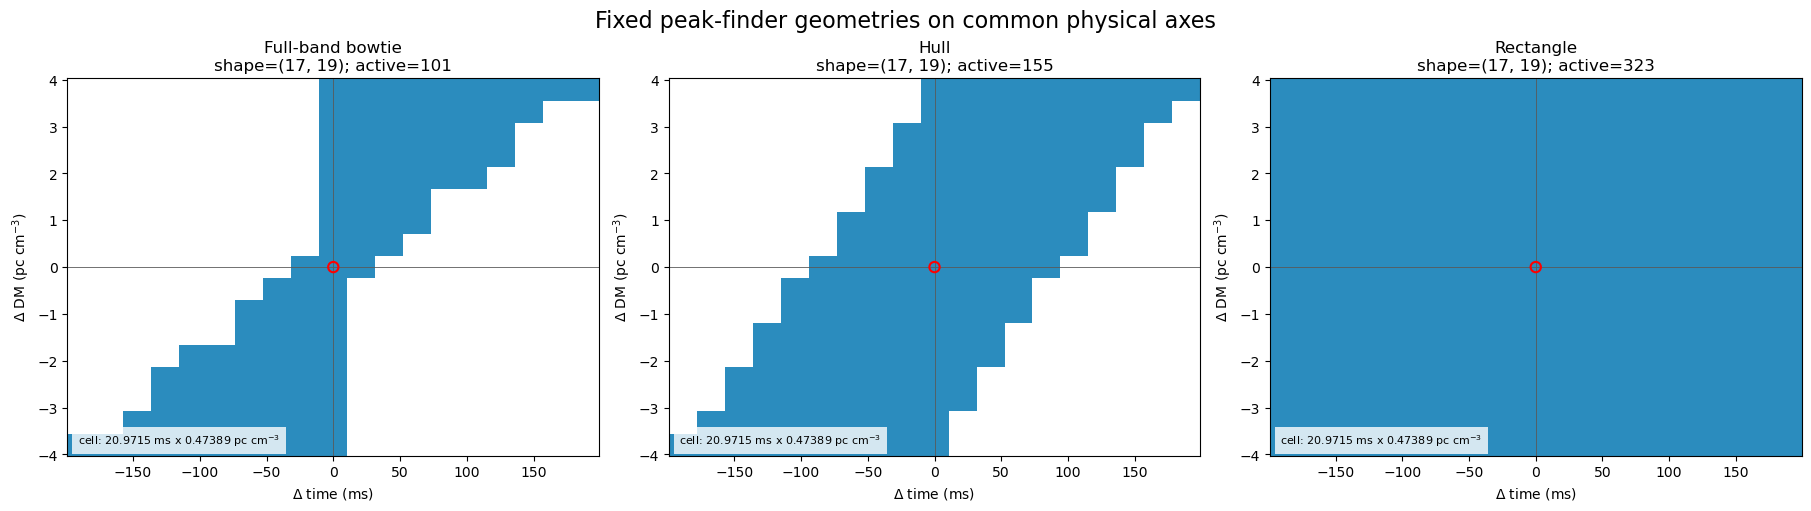

In [9]:
fixed_footprints = [
    ("Full-band bowtie", geometry.full_band_footprint),
    ("Hull", geometry.hull_footprint),
    ("Rectangle", geometry.rectangle_footprint),
]
max_dm_radius = max(footprint.shape[0] // 2 for _, footprint in fixed_footprints)
max_time_radius = max(footprint.shape[1] // 2 for _, footprint in fixed_footprints)
common_footprint_xlim = (
    -(max_time_radius + 0.5) * time_step_s * 1.0e3,
    +(max_time_radius + 0.5) * time_step_s * 1.0e3,
)
common_footprint_ylim = (
    -(max_dm_radius + 0.5) * dm_step,
    +(max_dm_radius + 0.5) * dm_step,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (name, footprint) in zip(axes, fixed_footprints):
    plot_footprint_physical(
        ax,
        footprint,
        name,
        xlim=common_footprint_xlim,
        ylim=common_footprint_ylim,
    )
fig.suptitle("Fixed peak-finder geometries on common physical axes", fontsize=16)
plt.show()


## What `dm_reach` changes

This is a map-grid parameter. For each requested value below, the current
module regenerates the selected tree's **direct full-band** bowtie while keeping
`WAIST_BINS` fixed. The number of rows is `2 * dm_reach + 1`, and the physical
half-reach is `dm_reach * dm_step` -- not `dm_reach` pc cm$^{-3}$.


dm_reach,number of DM rows,physical DM half-reach (pc cm^-3),mask shape,maximum |time| reach (bins),maximum |time| reach (ms),active cells,mask occupancy
1,3,0.47389033187363694,"(3, 5)",2,41.94304,9,0.6
2,5,0.9477806637472739,"(5, 7)",3,62.91456000000001,17,0.4857142857142857
4,9,1.8955613274945478,"(9, 11)",5,104.85759999999999,37,0.37373737373737376
8,17,3.7911226549890955,"(17, 19)",9,188.74367999999998,101,0.3126934984520124
16,33,7.582245309978191,"(33, 35)",17,356.51584,325,0.2813852813852814


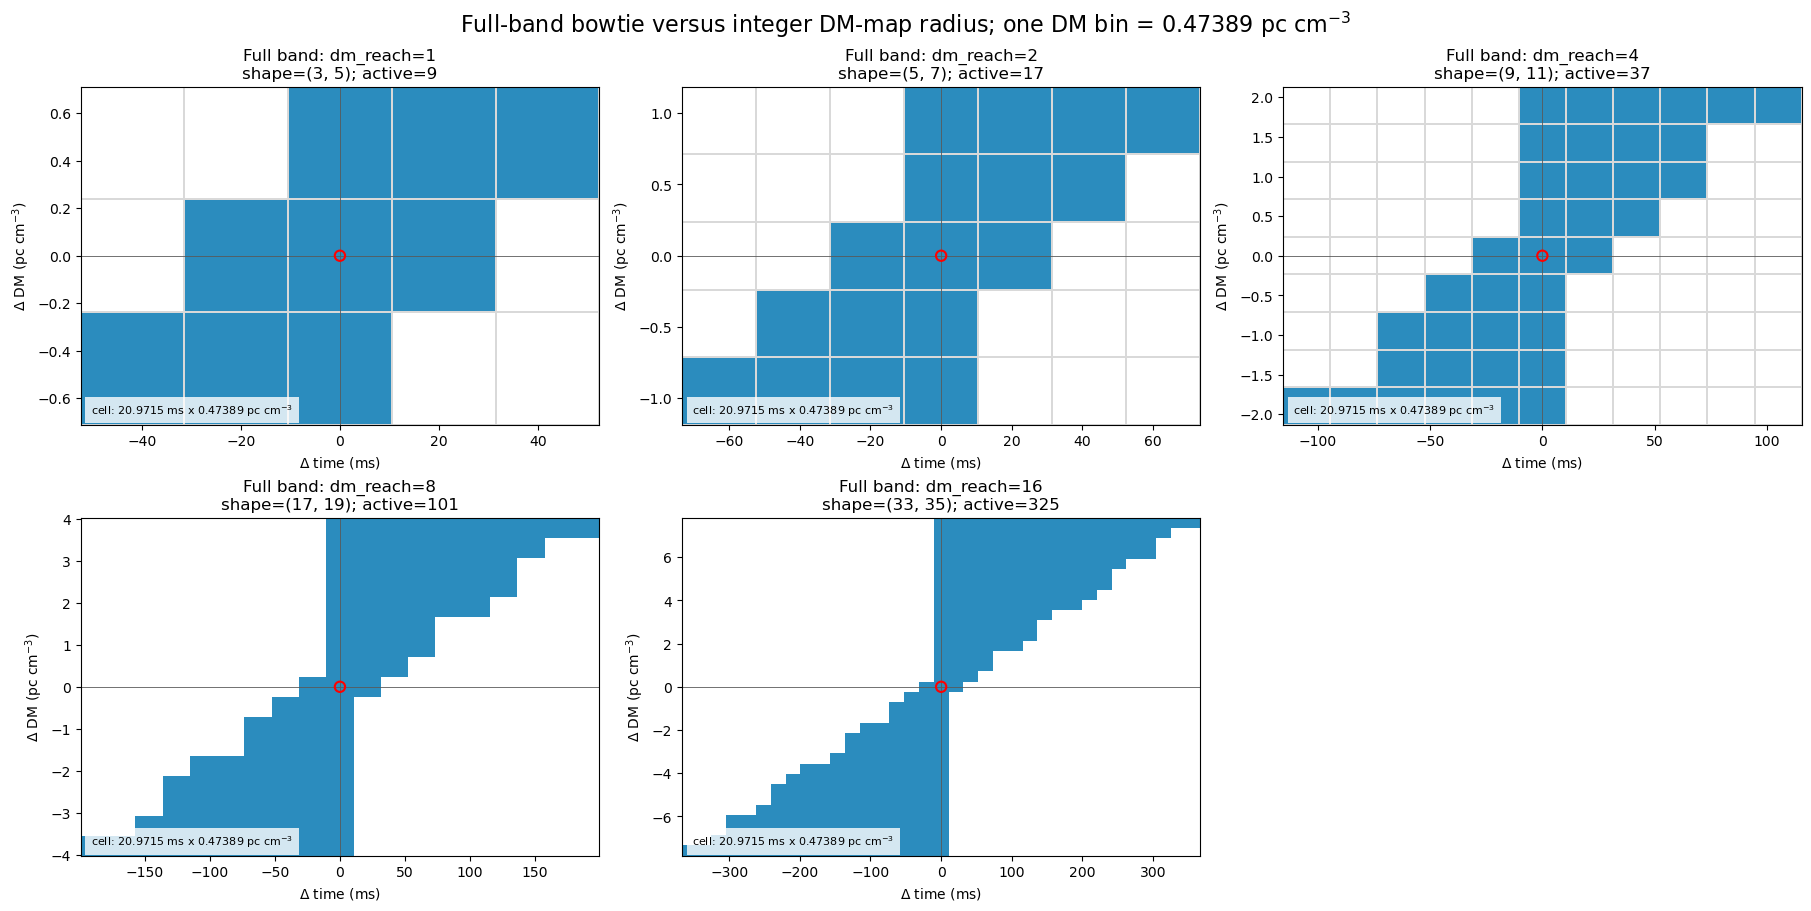

In [10]:
full_band = geometry.subbands[geometry.full_band_index]
with cp.cuda.Device(GPU_DEVICE):
    reach_footprints = {
        reach: pf.make_subband_bowtie_gpu(
            reach,
            dm_step,
            time_step_s,
            full_band.freq_lo_MHz,
            full_band.freq_hi_MHz,
            reference_freq_mhz,
            WAIST_BINS,
        )
        for reach in DM_REACH_VALUES
    }

reach_rows = []
for reach, footprint in reach_footprints.items():
    mask, active_cells = footprint_stats_cpu(footprint)
    center = np.asarray(mask.shape) // 2
    active = np.argwhere(mask)
    max_time_reach_bins = int(np.max(np.abs(active[:, 1] - center[1])))
    reach_rows.append({
        "dm_reach": reach,
        "number of DM rows": 2 * reach + 1,
        "physical DM half-reach (pc cm^-3)": reach * dm_step,
        "mask shape": str(mask.shape),
        "maximum |time| reach (bins)": max_time_reach_bins,
        "maximum |time| reach (ms)": max_time_reach_bins * time_step_s * 1.0e3,
        "active cells": active_cells,
        "mask occupancy": active_cells / mask.size,
    })

reach_table = Table(reach_rows)
display(reach_table)

nreach = len(reach_footprints)
ncols = min(3, nreach)
nrows = int(np.ceil(nreach / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), constrained_layout=True
)
axes = np.atleast_1d(axes).reshape(-1)
for ax, (reach, footprint) in zip(axes, reach_footprints.items()):
    plot_footprint_physical(ax, footprint, f"Full band: dm_reach={reach}")
for ax in axes[nreach:]:
    ax.set_visible(False)
fig.suptitle(
    f"Full-band bowtie versus integer DM-map radius; "
    f"one DM bin = {dm_step:.6g} pc cm$^{{-3}}$",
    fontsize=16,
)
plt.show()


## Apply the four current methods to the generated map

The simulator-produced `snr_gpu` and `argmax_gpu` remain GPU-resident. One
current `PeakFinderGeometry` and exactly the same two GPU objects are passed to
all four methods. Candidate selection is exclusively through
`pf.run_peakfinder`; decoding is exclusively through `pf.decode_candidates`.
No threshold or geometry parameter is retuned for the analytic map.


In [11]:
if snr_gpu.shape != argmax_gpu.shape:
    raise AssertionError("GPU S/N and argmax shapes disagree")
if snr_gpu.shape != (geometry.ndm, geometry.nt):
    raise AssertionError("GPU maps disagree with the current geometry")
if argmax_gpu.dtype != cp.uint32:
    raise AssertionError("GPU argmax dtype is not uint32")

input_pointers = {}
candidates_by_method = {}
with cp.cuda.Device(GPU_DEVICE):
    for method in pf.METHODS:
        input_pointers[method] = (int(snr_gpu.data.ptr), int(argmax_gpu.data.ptr))
        candidates_by_method[method] = pf.run_peakfinder(
            method,
            snr_gpu,
            argmax_gpu,
            geometry,
            SNR_THRESHOLD,
            edge_policy=EDGE_POLICY,
        )

if len(set(input_pointers.values())) != 1:
    raise AssertionError("The four methods did not receive the same GPU map objects")

candidate_containment_passed = pf.validate_candidate_set_containment(
    candidates_by_method,
    context=f"fast analytic trial {TRIAL}, tree {TREE_INDEX}",
)
candidate_counts = {
    method: len(candidates_by_method[method]) for method in pf.METHODS
}
decoded_by_method = {
    method: pf.decode_candidates(
        plan,
        candidates,
        itree=TREE_INDEX,
        time_chunk_index=time_chunk_index,
        ntime=nt_in,
        time_sample_s=time_sample_s,
    )
    for method, candidates in candidates_by_method.items()
}

bank_coordinates = pf.candidate_coordinate_set(
    candidates_by_method["bowtie_banks"]
)
full_coordinates = pf.candidate_coordinate_set(
    candidates_by_method["full_band_bowtie"]
)
bank_full_agree_exactly = bank_coordinates == full_coordinates
if not bank_full_agree_exactly:
    raise AssertionError(
        "Full-band-only synthetic tokens should make Bowtie banks and "
        "Full-band bowtie agree exactly"
    )

print("Candidate counts:")
for method in pf.METHODS:
    print(f"  {pf.METHOD_LABELS[method]}: {candidate_counts[method]}")
print("PASS: candidate-coordinate containment holds.")
print("PASS: Bowtie banks and Full-band bowtie agree exactly.")


Candidate counts:
  Bowtie banks: 6
  Full-band bowtie: 6
  Hull: 4
  Rectangle: 4
PASS: candidate-coordinate containment holds.
PASS: Bowtie banks and Full-band bowtie agree exactly.


## Per-method GPU timing

Geometry construction, analytic-map generation, decoding, plotting, and table
formatting are outside these timings. After warm-up, CUDA events measure the
GPU work required for each `pf.run_peakfinder()` call on the same resident map;
the stop event is synchronized on every measured iteration.


In [12]:
def time_peakfinder_gpu(method):
    with cp.cuda.Device(GPU_DEVICE):
        for _ in range(TIMING_WARMUP_RUNS):
            warmup = pf.run_peakfinder(
                method, snr_gpu, argmax_gpu, geometry, SNR_THRESHOLD,
                edge_policy=EDGE_POLICY,
            )
        synchronize_gpu()
        del warmup

        elapsed_ms = []
        for _ in range(TIMING_MEASURED_RUNS):
            start_event = cp.cuda.Event()
            stop_event = cp.cuda.Event()
            start_event.record()
            measured = pf.run_peakfinder(
                method, snr_gpu, argmax_gpu, geometry, SNR_THRESHOLD,
                edge_policy=EDGE_POLICY,
            )
            stop_event.record()
            stop_event.synchronize()
            elapsed_ms.append(float(cp.cuda.get_elapsed_time(start_event, stop_event)))
            del measured
    values = np.asarray(elapsed_ms, dtype=np.float64)
    return {
        "method": method,
        "warm-up runs": TIMING_WARMUP_RUNS,
        "measured runs": TIMING_MEASURED_RUNS,
        "median GPU time (ms)": float(np.median(values)),
        "minimum GPU time (ms)": float(np.min(values)),
        "maximum GPU time (ms)": float(np.max(values)),
    }


peakfinder_timing_rows = [
    time_peakfinder_gpu(method) for method in pf.METHODS
]
peakfinder_timing_ms = {
    row["method"]: row["median GPU time (ms)"]
    for row in peakfinder_timing_rows
}
display(Table(peakfinder_timing_rows))


method,warm-up runs,measured runs,median GPU time (ms),minimum GPU time (ms),maximum GPU time (ms)
bowtie_banks,3,20,7.609871864318848,7.574528217315674,7.802879810333252
full_band_bowtie,3,20,0.5165600180625916,0.5038080215454102,0.5283200144767761
hull,3,20,0.5386239886283875,0.5305600166320801,0.5540480017662048
rectangle,3,20,0.5412800014019012,0.5263360142707825,0.5529599785804749


## Final map-level result

The background in every panel is the same generated `out_max`, with identical
normalization and plan-derived physical coarse-cell edges. Final candidates are
open circles at decoded physical DM and decoded reference-frequency TOA. Red
crosses and dashed lines mark all three injected coordinates.


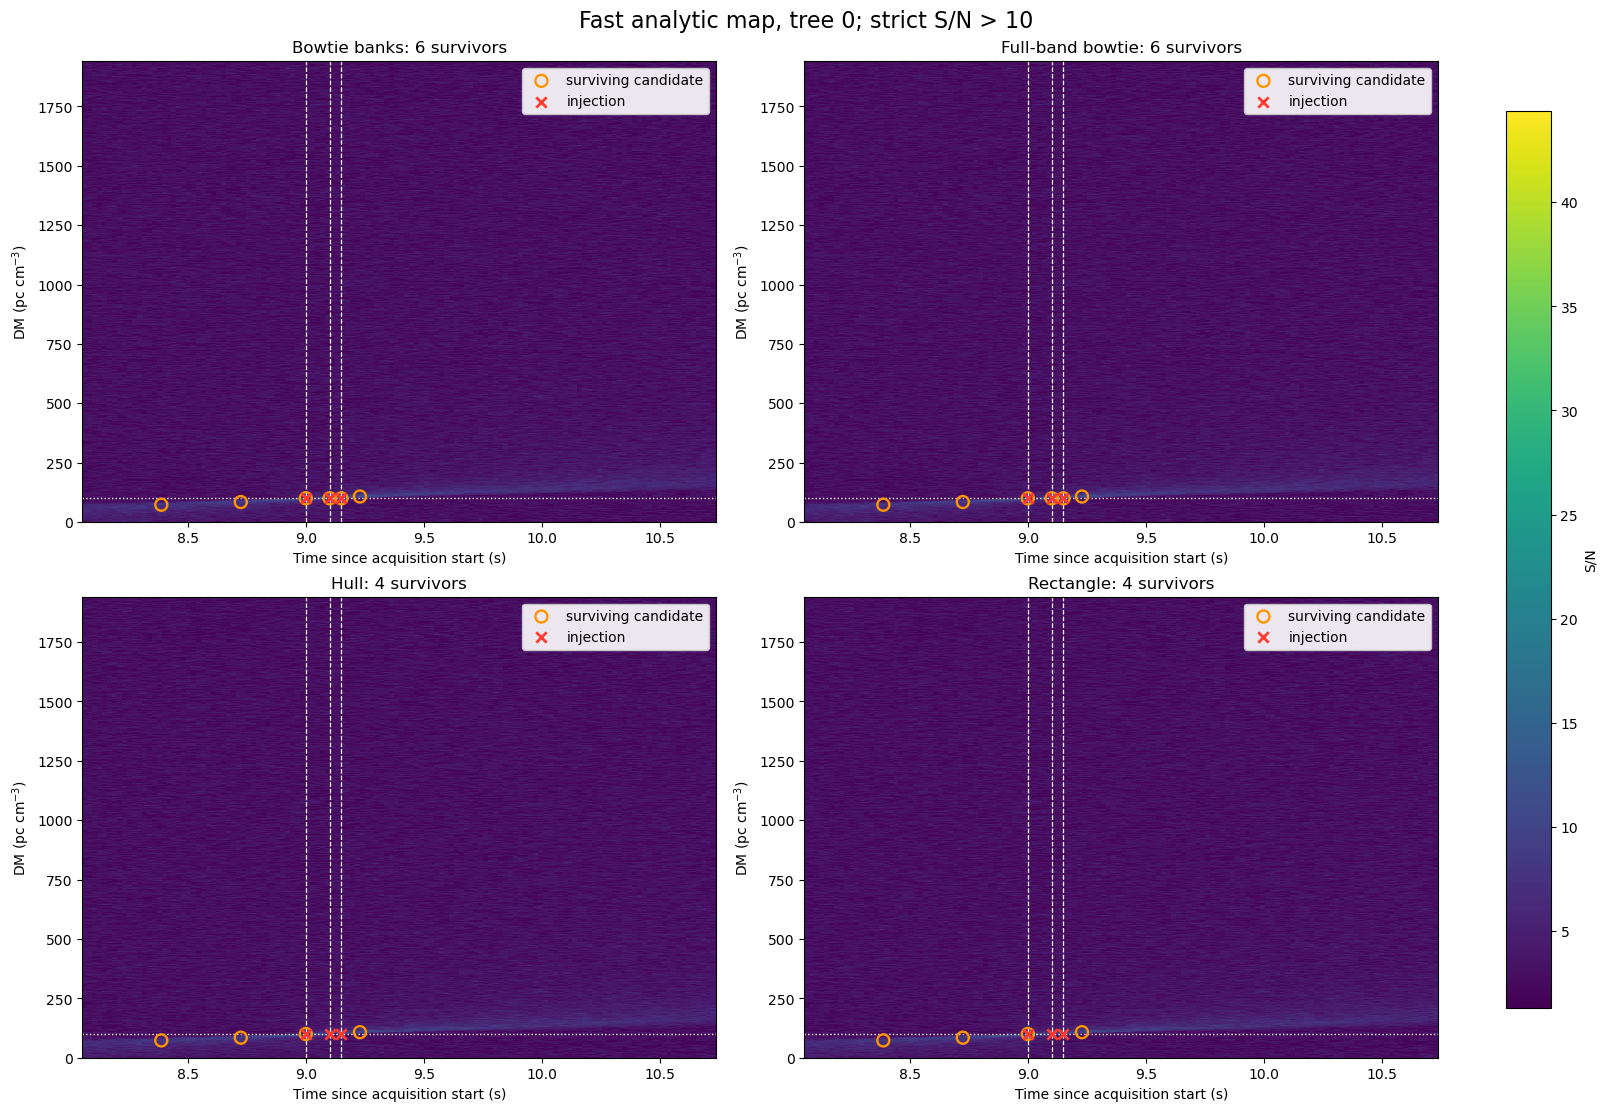

In [13]:
if TIME_WINDOW_S is None:
    common_time_limits = (float(time_edges[0]), float(time_edges[-1]))
else:
    if len(TIME_WINDOW_S) != 2 or not TIME_WINDOW_S[0] < TIME_WINDOW_S[1]:
        raise ValueError("TIME_WINDOW_S must be None or an increasing pair")
    common_time_limits = tuple(map(float, TIME_WINDOW_S))

if DM_WINDOW is None:
    common_dm_limits = (float(dm_edges[0]), float(dm_edges[-1]))
else:
    if len(DM_WINDOW) != 2 or not DM_WINDOW[0] < DM_WINDOW[1]:
        raise ValueError("DM_WINDOW must be None or an increasing pair")
    common_dm_limits = tuple(map(float, DM_WINDOW))

if not (np.all(np.isfinite(snr_cpu))
        and np.all(np.isfinite(dm_edges))
        and np.all(np.isfinite(time_edges))
        and np.all(np.isfinite(common_time_limits))
        and np.all(np.isfinite(common_dm_limits))):
    raise AssertionError("A plotted map value or physical edge is non-finite")
for method, decoded in decoded_by_method.items():
    for field in ("snr", "dm", "toa_ref_s", "width_s", "freq_lo_MHz", "freq_hi_MHz"):
        if not np.all(np.isfinite(decoded[field])):
            raise AssertionError(f"{method}: decoded field {field} is non-finite")

snr_norm = Normalize(
    vmin=float(np.percentile(snr_cpu, 1.0)),
    vmax=float(np.max(snr_cpu)),
)


def plot_method_panel(ax, method, *, time_limits, dm_limits):
    image = ax.pcolormesh(
        time_edges, dm_edges, snr_cpu, cmap="viridis", norm=snr_norm,
        shading="flat", rasterized=True,
    )
    decoded = decoded_by_method[method]
    ax.scatter(
        decoded["toa_ref_s"], decoded["dm"], marker="o", facecolors="none",
        edgecolors="#ff9500", linewidths=1.7, s=75, zorder=4,
        label="surviving candidate",
    )
    mark_injections(ax)
    ax.set(
        title=f"{pf.METHOD_LABELS[method]}: {candidate_counts[method]} survivors",
        xlabel="Time since acquisition start (s)",
        ylabel=r"DM (pc cm$^{-3}$)",
        xlim=time_limits,
        ylim=dm_limits,
    )
    ax.legend(loc="upper right", framealpha=0.9)
    return image


fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
axes = axes.reshape(-1)
for ax, method in zip(axes, pf.METHODS):
    image = plot_method_panel(
        ax, method, time_limits=common_time_limits, dm_limits=common_dm_limits
    )
colorbar = fig.colorbar(image, ax=axes.tolist(), shrink=0.9)
colorbar.set_label("S/N")
fig.suptitle(
    f"Fast analytic map, tree {TREE_INDEX}; strict S/N > {SNR_THRESHOLD:g}",
    fontsize=16,
)
plt.show()

all_plotted_physical_values_finite = True


## Burst-region comparison

The same four-panel layout, color normalization, decoded markers, and injection
markers are repeated with identical zoom limits around the three bursts. This is
the direct visual separability view; it does not change candidate selection.


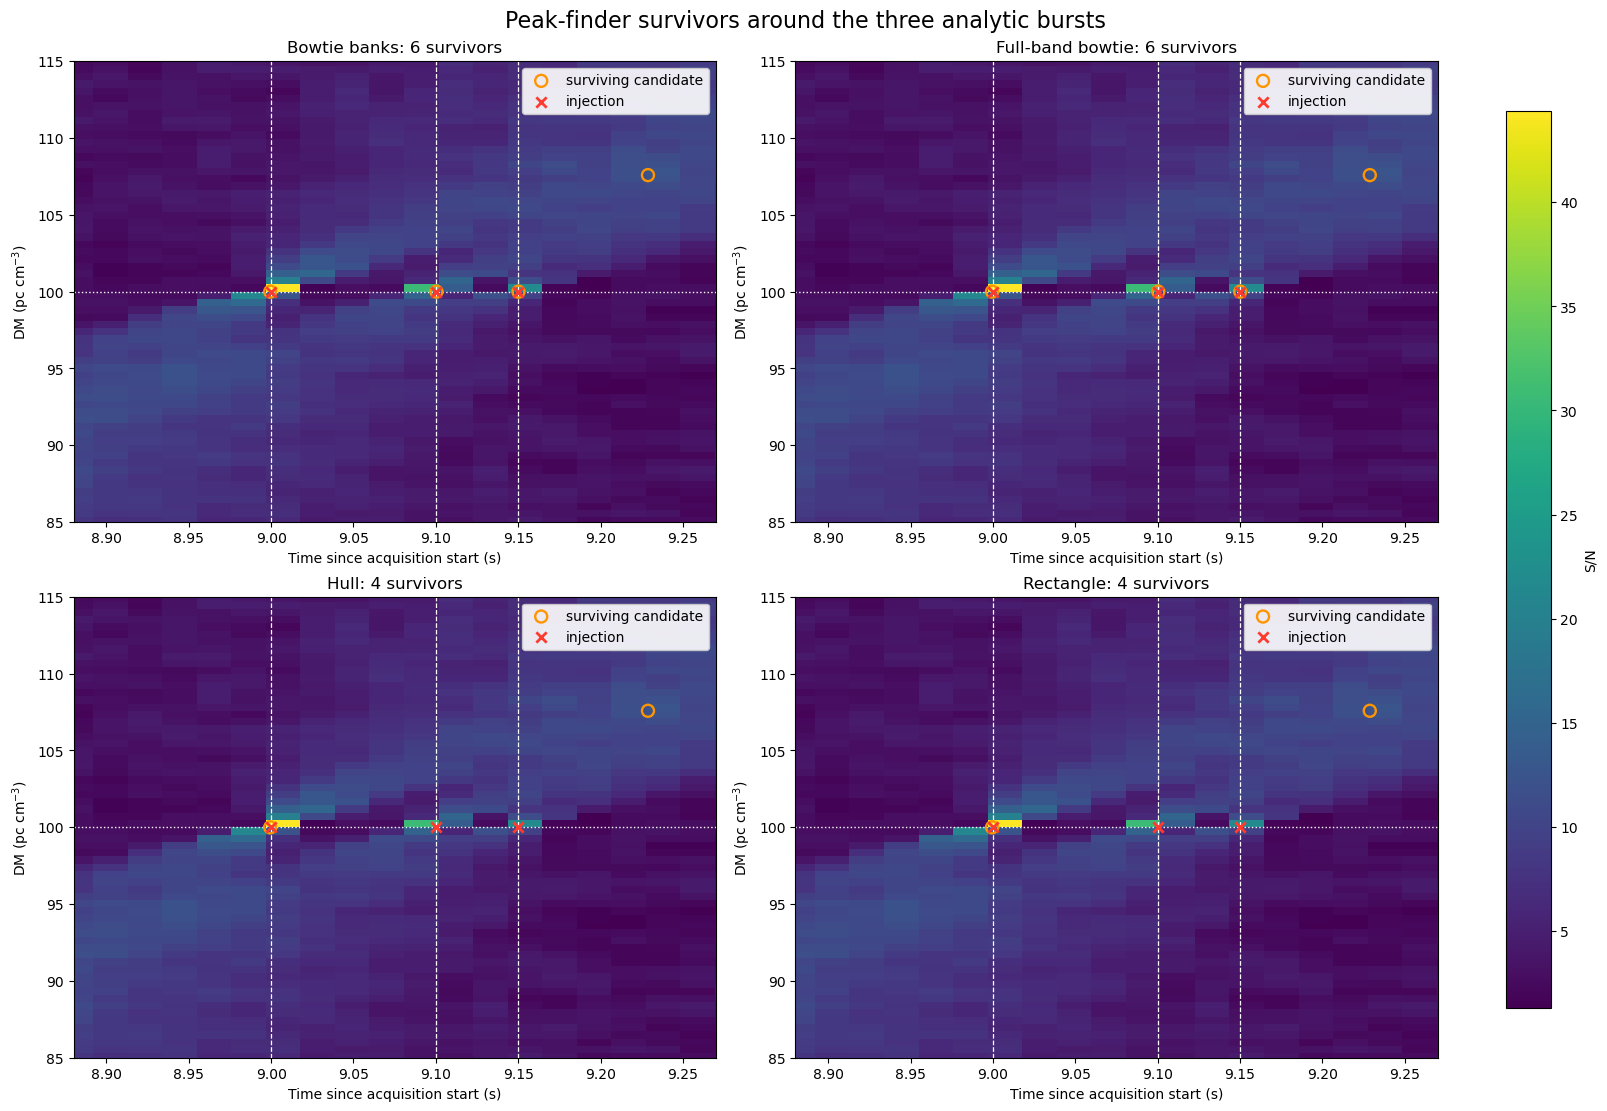

In [14]:
burst_time_limits = (
    min(INJECTED_TOAS_S) - 0.12,
    max(INJECTED_TOAS_S) + 0.12,
)
burst_dm_limits = (INJECTED_DM - 15.0, INJECTED_DM + 15.0)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
axes = axes.reshape(-1)
for ax, method in zip(axes, pf.METHODS):
    image = plot_method_panel(
        ax, method, time_limits=burst_time_limits, dm_limits=burst_dm_limits
    )
colorbar = fig.colorbar(image, ax=axes.tolist(), shrink=0.9)
colorbar.set_label("S/N")
fig.suptitle("Peak-finder survivors around the three analytic bursts", fontsize=16)
plt.show()


### Timestamp and sub-cell coordinate convention

`pf.decode_candidates` uses PIRATE's `decode_argmax_batch` and
`decode_argmax2_batch`; it does not approximate physical parameters from coarse
cell centres. `toa_ref_s` is the arrival time at the lowest X-engine channel
edge, in seconds since the beginning of the acquisition. The decoder's
chunk-relative sample timestamp is converted with `time_sample_s`, then offset
by `time_chunk_index * nt_in * time_sample_s`.

A marker need not lie exactly at a coarse map-cell centre. Synthetic `out_max`
and `out_argmax` preserve the winning fine DM/time state inside each coarse
output cell, so the decoded coordinate is more specific than `(idm, itime)`.


In [15]:
candidate_rows = []
for method in pf.METHODS:
    decoded = decoded_by_method[method]
    for index in range(decoded["snr"].size):
        candidate_rows.append({
            "method": method,
            "S/N": float(decoded["snr"][index]),
            "coarse idm": int(decoded["idm"][index]),
            "coarse itime": int(decoded["itime"][index]),
            "decoded DM (pc cm^-3)": float(decoded["dm"][index]),
            "decoded TOA since acquisition start (s)": float(decoded["toa_ref_s"][index]),
            "decoded width (ms)": float(decoded["width_s"][index]) * 1.0e3,
            "profile": int(decoded["profile"][index]),
            "fmin": int(decoded["fmin"][index]),
            "fmax": int(decoded["fmax"][index]),
            "winning frequency lower edge (MHz)": float(decoded["freq_lo_MHz"][index]),
            "winning frequency upper edge (MHz)": float(decoded["freq_hi_MHz"][index]),
            "argmax token": int(decoded["argmax_token"][index]),
            "_method_order": pf.METHODS.index(method),
        })

candidate_columns = [
    "method", "S/N", "coarse idm", "coarse itime",
    "decoded DM (pc cm^-3)", "decoded TOA since acquisition start (s)",
    "decoded width (ms)", "profile", "fmin", "fmax",
    "winning frequency lower edge (MHz)",
    "winning frequency upper edge (MHz)", "argmax token",
]
candidate_rows.sort(key=lambda row: (row["_method_order"], -row["S/N"]))
candidate_table = Table(
    [
        {column: row[column] for column in candidate_columns}
        for row in candidate_rows
    ],
    candidate_columns,
)
display(candidate_table.head(MAX_TABLE_ROWS))
if len(candidate_table) > MAX_TABLE_ROWS:
    print(
        f"Displayed {MAX_TABLE_ROWS} of {len(candidate_table)} rows; "
        "increase MAX_TABLE_ROWS in the parameter cell to see more."
    )


method,S/N,coarse idm,coarse itime,decoded DM (pc cm^-3),decoded TOA since acquisition start (s),decoded width (ms),profile,fmin,fmax,winning frequency lower edge (MHz),winning frequency upper edge (MHz),argmax token
bowtie_banks,44.39219665527344,211,45,99.99238578805999,8.999437280515146,2.62144,1,0,65535,300.0,1500.0,4915458
bowtie_banks,30.607759475708008,211,49,99.99238578805999,9.100362720515145,2.62144,1,0,65535,300.0,1500.0,4915471
bowtie_banks,21.818431854248047,211,52,99.99238578805999,9.150170080515146,2.62144,1,0,65535,300.0,1500.0,4915461
bowtie_banks,12.649206161499023,227,56,107.57474679568539,9.228815840554208,2.62144,1,0,65535,300.0,1500.0,4915457
bowtie_banks,11.01420783996582,178,32,84.3537662098326,8.724180800434578,2.62144,1,0,65535,300.0,1500.0,4915456
bowtie_banks,10.064960479736328,154,15,72.9802246983945,8.387321920375983,2.62144,1,0,65535,300.0,1500.0,4915471
full_band_bowtie,44.39219665527344,211,45,99.99238578805999,8.999437280515146,2.62144,1,0,65535,300.0,1500.0,4915458
full_band_bowtie,30.607759475708008,211,49,99.99238578805999,9.100362720515145,2.62144,1,0,65535,300.0,1500.0,4915471
full_band_bowtie,21.818431854248047,211,52,99.99238578805999,9.150170080515146,2.62144,1,0,65535,300.0,1500.0,4915461
full_band_bowtie,12.649206161499023,227,56,107.57474679568539,9.228815840554208,2.62144,1,0,65535,300.0,1500.0,4915457


## Time cut and temporal resolution at DM 100

The line is the deterministic analytic S/N at the decoded DM trial nearest
100 pc cm$^{-3}$. Vertical lines mark the three input TOAs. Method-colored
markers show every returned candidate near DM 100 at its decoded TOA and final
signal-plus-background S/N. Matching uses a one-output-bin TOA tolerance and a
two-DM-bin tolerance, with each candidate assignable to at most one injection.


method,matched all three,100 ms pair distinct,50 ms pair distinct,matched candidate indices
bowtie_banks,True,True,True,"[0, 1, 2]"
full_band_bowtie,True,True,True,"[0, 1, 2]"
hull,False,False,False,"[0, None, None]"
rectangle,False,False,False,"[0, None, None]"


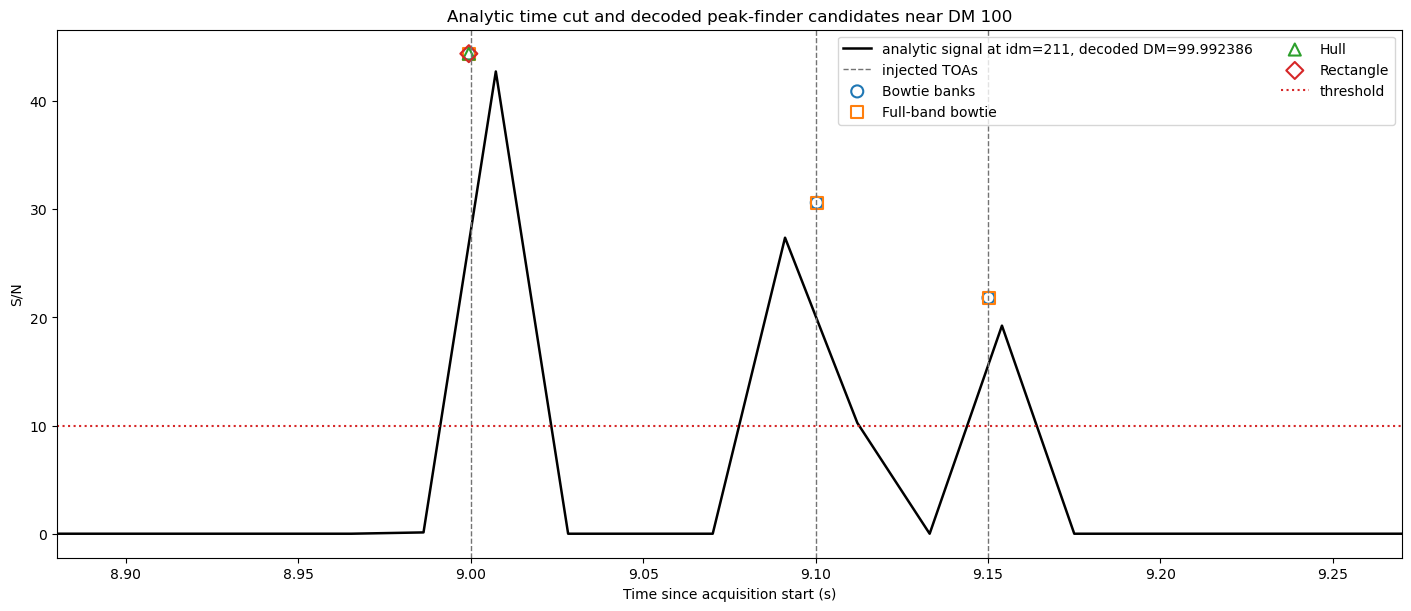

In [16]:
method_colors = {
    "bowtie_banks": "#1f77b4",
    "full_band_bowtie": "#ff7f0e",
    "hull": "#2ca02c",
    "rectangle": "#d62728",
}
method_markers = {
    "bowtie_banks": "o",
    "full_band_bowtie": "s",
    "hull": "^",
    "rectangle": "D",
}


def match_injections(decoded):
    matches = [None] * len(INJECTED_TOAS_S)
    used = set()
    for injection_index, toa_s in enumerate(INJECTED_TOAS_S):
        eligible = [
            candidate_index
            for candidate_index in range(decoded["snr"].size)
            if candidate_index not in used
            and abs(decoded["dm"][candidate_index] - INJECTED_DM) <= 2.0 * dm_step
            and abs(decoded["toa_ref_s"][candidate_index] - toa_s) <= time_step_s
        ]
        if eligible:
            best = min(
                eligible,
                key=lambda index: abs(decoded["toa_ref_s"][index] - toa_s),
            )
            matches[injection_index] = best
            used.add(best)
    return matches


resolution_rows = []
matches_by_method = {}
for method in pf.METHODS:
    matches = match_injections(decoded_by_method[method])
    matches_by_method[method] = matches
    pair_100_ms = (
        matches[0] is not None and matches[1] is not None
        and matches[0] != matches[1]
    )
    pair_50_ms = (
        matches[1] is not None and matches[2] is not None
        and matches[1] != matches[2]
    )
    resolution_rows.append({
        "method": method,
        "matched all three": all(index is not None for index in matches),
        "100 ms pair distinct": pair_100_ms,
        "50 ms pair distinct": pair_50_ms,
        "matched candidate indices": str(matches),
    })

display(Table(resolution_rows))

fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
ax.plot(
    time_centres_s,
    analytic_signal_cpu[target_idm],
    color="black",
    linewidth=1.8,
    label=(
        f"analytic signal at idm={target_idm}, "
        f"decoded DM={simulator.dm_axis_cpu[target_idm]:.6f}"
    ),
)
for index, toa_s in enumerate(INJECTED_TOAS_S):
    ax.axvline(
        toa_s, color="0.45", linestyle="--", linewidth=1.0,
        label="injected TOAs" if index == 0 else None,
    )
for method in pf.METHODS:
    decoded = decoded_by_method[method]
    near = np.abs(decoded["dm"] - INJECTED_DM) <= 2.0 * dm_step
    ax.scatter(
        decoded["toa_ref_s"][near],
        decoded["snr"][near],
        marker=method_markers[method],
        facecolors="none",
        edgecolors=method_colors[method],
        linewidths=1.5,
        s=75,
        label=pf.METHOD_LABELS[method],
    )
ax.axhline(SNR_THRESHOLD, color="#d62728", linestyle=":", label="threshold")
ax.set(
    title="Analytic time cut and decoded peak-finder candidates near DM 100",
    xlabel="Time since acquisition start (s)",
    ylabel="S/N",
    xlim=burst_time_limits,
)
ax.legend(ncol=2)
plt.show()

resolved_100_ms_by_method = {
    row["method"]: row["100 ms pair distinct"] for row in resolution_rows
}
resolved_50_ms_by_method = {
    row["method"]: row["50 ms pair distinct"] for row in resolution_rows
}


## Final four-method comparison

This table combines survivor counts, temporal resolution, strongest S/N, and
steady-state per-map GPU timing. The timing is descriptive for this one map and
does not constitute a benchmark campaign.


In [17]:
comparison_rows = []
for method in pf.METHODS:
    decoded = decoded_by_method[method]
    comparison_rows.append({
        "method": pf.METHOD_LABELS[method],
        "candidate count": candidate_counts[method],
        "strongest candidate S/N": (
            float(decoded["snr"][0]) if decoded["snr"].size else None
        ),
        "100 ms pair distinct": resolved_100_ms_by_method[method],
        "50 ms pair distinct": resolved_50_ms_by_method[method],
        "median GPU time (ms)": peakfinder_timing_ms[method],
        "same coordinates as Bowtie banks": (
            pf.candidate_coordinate_set(candidates_by_method[method])
            == bank_coordinates
        ),
    })
display(Table(comparison_rows))


method,candidate count,strongest candidate S/N,100 ms pair distinct,50 ms pair distinct,median GPU time (ms),same coordinates as Bowtie banks
Bowtie banks,6,44.39219665527344,True,True,7.609871864318848,True
Full-band bowtie,6,44.39219665527344,True,True,0.5165600180625916,True
Hull,4,44.39219665527344,False,False,0.5386239886283875,False
Rectangle,4,44.39219665527344,False,False,0.5412800014019012,False


## Final audit

Runtime assertions cover the real YAML-derived plan, direct GPU-map generation,
all footprint equalities, candidate containment, full-band token limitation,
physical finiteness, and burst localization. A final static audit checks that
the notebook contains no file-based map loading, end-to-end dedisperser call,
or out-of-scope peak-finder implementation.


In [18]:
import ast
import json


notebook_path = Path(
    "peakfinder_tests/inspect_peakfinders_on_fast_snrmap.ipynb"
)
with notebook_path.open("r", encoding="utf-8") as stream:
    saved_notebook = json.load(stream)
saved_code = "\n".join(
    "".join(cell.get("source", []))
    for cell in saved_notebook["cells"]
    if cell.get("cell_type") == "code"
)
syntax_tree = ast.parse(saved_code)

imported_modules = []
defined_functions = []
for node in ast.walk(syntax_tree):
    if isinstance(node, ast.Import):
        imported_modules.extend(alias.name for alias in node.names)
    elif isinstance(node, ast.ImportFrom):
        imported_modules.append(node.module or "")
    elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
        defined_functions.append(node.name)

if any(module == "asdf" or module.startswith("asdf.")
       for module in imported_modules):
    raise AssertionError("Fast-map notebook must not import a saved-map reader")
if any("OfflineDedisperser" in module for module in imported_modules):
    raise AssertionError("Fast-map notebook must not import the end-to-end dedisperser")
forbidden_definition_fragments = ("connected_" + "component", "max_" + "pool")
if any(
        fragment in function_name.lower()
        for function_name in defined_functions
        for fragment in forbidden_definition_fragments):
    raise AssertionError("Notebook defines an out-of-scope peak finder")

required_passes = {
    "YAML plan selects tree 0": TREE_INDEX == 0,
    "nt_in is 2048": nt_in == 2048,
    "all TOAs independently fall in chunk 3": set(derived_chunks) == {3},
    "generated GPU dtypes and shapes": (
        snr_gpu.dtype == cp.float32
        and argmax_gpu.dtype == cp.uint32
        and snr_gpu.shape == argmax_gpu.shape == (ndm_out, nt_out)
    ),
    "all three injections appear near requested DM/TOA": injection_locations_passed,
    "same GPU maps passed to all methods": len(set(input_pointers.values())) == 1,
    "footprint checks": footprint_containment_passed,
    "candidate containment": candidate_containment_passed,
    "local geometry reproduces module": geometry_reproduction_passed,
    "Bowtie banks equal Full-band on full-band tokens": bank_full_agree_exactly,
    "all plotted physical values finite": all_plotted_physical_values_finite,
    "no file-based map-reader import": True,
    "no end-to-end dedisperser import": True,
    "no out-of-scope peak-finder definitions": True,
}
if not all(required_passes.values()):
    raise AssertionError(required_passes)

display(Table([
    {"check": check, "passed": passed}
    for check, passed in required_passes.items()
]))

summary_rows = [
    {"quantity": "selected tree", "value": TREE_INDEX},
    {
        "quantity": "observing band (MHz)",
        "value": f"{observing_freq_lo_mhz:g}--{observing_freq_hi_mhz:g}",
    },
    {"quantity": "DM step (pc cm^-3)", "value": dm_step},
    {"quantity": "output time step (ms)", "value": time_step_s * 1.0e3},
    {"quantity": "simulator construction (ms)", "value": simulator_construction_time_ms},
    {"quantity": "deterministic template (ms)", "value": template_generation_time_ms},
    {"quantity": "background plus map (ms)", "value": map_generation_time_ms},
    {"quantity": "original sub-band bowties", "value": len(geometry.subbands)},
    {"quantity": "exactly unique sub-band bowties", "value": len(geometry.unique_footprints)},
]
summary_rows.extend(
    {"quantity": f"local S/N near TOA {row['injected TOA (s)']:.3f} s",
     "value": row["local maximum S/N"]}
    for row in local_peak_rows
)
summary_rows.extend(
    {"quantity": f"candidates: {method}", "value": candidate_counts[method]}
    for method in pf.METHODS
)
display(Table(summary_rows))
print("All required fast-map notebook checks pass.")


check,passed
YAML plan selects tree 0,True
nt_in is 2048,True
all TOAs independently fall in chunk 3,True
generated GPU dtypes and shapes,True
all three injections appear near requested DM/TOA,True
same GPU maps passed to all methods,True
footprint checks,True
candidate containment,True
local geometry reproduces module,True
Bowtie banks equal Full-band on full-band tokens,True


quantity,value
selected tree,0
observing band (MHz),300--1500
DM step (pc cm^-3),0.47389033187363694
output time step (ms),20.97152
simulator construction (ms),9.059475967660546
deterministic template (ms),102.60270501021296
background plus map (ms),13.438303954899311
original sub-band bowties,25
exactly unique sub-band bowties,25
local S/N near TOA 9.000 s,44.39219665527344


All required fast-map notebook checks pass.
